# Notebook 2 — Hypotheses and observability limits

**What this notebook establishes:** the stress tests of the baseline EKF that motivate
every downstream choice.

- **H4a — sensor-noise robustness:** how estimation degrades as ethanol noise grows; the noise floor.
- **H4b — sensor-drift robustness:** three drift scenarios and the rate at which the filter is misled.
- **H1 — observability limit:** promoting **dissolved oxygen** and then **CO₂** to *estimated states*
  and showing their covariance grows unbounded from ethanol-only data — i.e. they are
  **unobservable**. This is the theorem behind *Design B* (measured inputs, not states) used in
  Notebooks 4–5. A **Morris elementary-effects** screen ranks which parameters actually matter.

> The first cells (§ Module 1–7) re-run the full baseline from Notebook 1 so this notebook runs
> **standalone** — the hypothesis sections below reuse the baseline ground truth, EKF loop, and
> `t_offline` sampling grid. The hypotheses proper begin at **H4a**. See `README.md` §7.

*Notebook shipped unexecuted — run top to bottom.*


## Module 1 — Imports & Parameters
### 1.1 Import libraries
We need four libraries:
- `numpy` — numerical arrays and matrix operations
- `scipy` — ODE integration (`solve_ivp`) and interpolation
- `sympy` — symbolic mathematics (for computing the Jacobian F)
- `matplotlib` — plotting results


In [2]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from scipy.integrate import solve_ivp

import sympy as sp

# Make plots look clean
plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 12,
    'axes.grid': True,
    'grid.alpha': 0.4,
    'figure.dpi': 120
})
print("All libraries loaded successfully.")


All libraries loaded successfully.


### 1.2 Parameter definitions
All values come directly from the paper.

**Two sets of yield coefficients are defined:**
- `_paper` suffix: values from Table 2 in the paper text (Y_X/G=0.17, Y_E/G=0.46, Y_X/E=0.60)
- `_code` suffix: values from the actual MATLAB code (Ygx=0.15, Yge=0.34, Yex=0.43)

We will try both and compare which reproduces Fig. 4 better.


In [3]:
# ── Monod half-saturation constants (Table 2) ─────────────────────────────
KG  = 0.1    # [g/L] — glucose half-saturation constant
KE  = 0.1    # [g/L] — ethanol half-saturation constant

# ── Yield coefficients — Paper Table 2 values ─────────────────────────────
Ygx_paper = 0.17   # Y_X/G — biomass yield from glucose
Yge_paper = 0.46   # Y_E/G — ethanol yield from glucose
Yex_paper = 0.60   # Y_X/E — biomass yield from ethanol

# ── Yield coefficients — MATLAB code values (differ from paper!) ───────────
Ygx_code  = 0.15   # slightly lower than paper
Yge_code  = 0.34   # significantly lower than paper
Yex_code  = 0.43   # significantly lower than paper

# ── Choose which set to use (change this to compare) ──────────────────────
USE_CODE_PARAMS = False   # set False to use paper Table 2 values

if USE_CODE_PARAMS:
    Ygx, Yge, Yex = Ygx_code, Yge_code, Yex_code
    print("Using MATLAB code parameter values")
else:
    Ygx, Yge, Yex = Ygx_paper, Yge_paper, Yex_paper
    print("Using paper Table 2 parameter values")

print(f"  Ygx = {Ygx}  |  Yge = {Yge}  |  Yex = {Yex}")

# ── Initial state vector x[0] ─────────────────────────────────────────────
# Order: [X, G, E, mu_max_G, mu_max_E]
X0      = 2.5    # [g/L]   initial biomass
G0      = 5.0    # [g/L]   initial glucose
E0      = 0.2    # [g/L]   initial ethanol (near zero)
mu_G0   = 0.15   # [1/h]   initial guess for mu_max_G
mu_E0   = 0.08   # [1/h]   initial guess for mu_max_E

x0 = np.array([X0, G0, E0, mu_G0, mu_E0])
print(f"\nInitial state x0 = {x0}")

# ── Initial covariance matrix P[0] ────────────────────────────────────────
# Diagonal values = expected variance of initial estimate for each variable
# P[0] for mu_max_G is largest because biological parameters are most uncertain
P0 = np.diag([0.1,    # biomass uncertainty
              0.02,   # glucose uncertainty  
              0.02,   # ethanol uncertainty
              0.2,    # mu_max_G uncertainty (highest — hardest to know)
              0.02])  # mu_max_E uncertainty

print(f"\nInitial P[0] diagonal = {np.diag(P0)}")

# ── EKF noise matrices ────────────────────────────────────────────────────
# Q: process noise covariance — how much we distrust the model per step
Q = np.diag([0.001, 0.001, 0.001, 0.001, 0.001])

# R: measurement noise variance — how noisy the ethanol sensor is
R = np.array([[0.1]])   # single value since we only measure ethanol

# ── Observation matrix H ─────────────────────────────────────────────────
# H picks out ethanol (index 2) from the state vector
H = np.array([[0, 0, 1, 0, 0]])   # shape (1, 5)

print("\nAll parameters defined successfully.")


Using paper Table 2 parameter values
  Ygx = 0.17  |  Yge = 0.46  |  Yex = 0.6

Initial state x0 = [2.5  5.   0.2  0.15 0.08]

Initial P[0] diagonal = [0.1  0.02 0.02 0.2  0.02]

All parameters defined successfully.


## Module 2 — Process Model (Equation 19)
The process model describes the biological dynamics of yeast cultivation.
It consists of 5 ODEs — 3 for concentrations and 2 for growth rate parameters.

### Monod kinetics (Equations 20 & 21)
- **μG** = μmax,G · G / (KG + G) — actual growth rate on glucose
- **μE** = μmax,E · E / (KE + E) · (1 − μG/μmax,G) — actual growth rate on ethanol

Note: the MATLAB code uses a **linear** suppression term (1 − μG/μmax,G),
while the paper equation 21 uses a **squared** term (1 − μG/μmax,G)².
We implement both and you can switch between them.


In [4]:
def monod_rates(X, G, E, mu_max_G, mu_max_E, use_squared_suppression=False):
    """
    Compute the actual Monod growth rates mu_G and mu_E.
    
    Parameters
    ----------
    X, G, E       : current concentrations [g/L]
    mu_max_G/E    : maximum growth rate parameters [1/h]
    use_squared   : if True use paper Eq.21 (squared), else use code (linear)
    
    Returns
    -------
    mu_G, mu_E    : actual growth rates [1/h]
    """
    # Standard Monod for glucose (Eq. 20)
    mu_G = mu_max_G * G / (KG + G)
    
    # Monod for ethanol with diauxic suppression (Eq. 21)
    # Suppression term: yeast ignores ethanol while glucose is available
    suppression = (1 - mu_G / mu_max_G)
    if use_squared_suppression:
        suppression = suppression ** 2   # paper Eq. 21
    # else: linear — as in the MATLAB code
    
    mu_E = mu_max_E * E / (KE + E) * suppression
    
    return mu_G, mu_E


def process_model(t, state):
    """
    The 5-ODE process model — Equation 19 from the paper.
    This is f(x) in the continuous-discrete EKF framework.
    
    State vector: [X, G, E, mu_max_G, mu_max_E]
    
    Returns the time derivative of each state variable.
    """
    X, G, E, mu_max_G, mu_max_E = state
    
    # Compute actual growth rates from Monod kinetics
    mu_G, mu_E = monod_rates(X, G, E, mu_max_G, mu_max_E)
    
    # ── The 5 ODEs ─────────────────────────────────────────────────────────
    dX_dt      = (mu_G + mu_E) * X              # Biomass grows from both substrates
    dG_dt      = -(mu_G / Ygx) * X              # Glucose only decreases
    dE_dt      = (mu_G * Yge / Ygx - mu_E / Yex) * X  # Ethanol: produced then consumed
    dmu_G_dt   = 0.0                             # dp/dt = 0 — Eq. 17
    dmu_E_dt   = 0.0                             # dp/dt = 0 — Eq. 17
    
    return [dX_dt, dG_dt, dE_dt, dmu_G_dt, dmu_E_dt]


# ── Quick sanity check at initial conditions ──────────────────────────────
derivatives_at_t0 = process_model(0, x0)
labels = ['dX/dt', 'dG/dt', 'dE/dt', 'dmu_G/dt', 'dmu_E/dt']
print("Derivatives at t=0 (initial conditions):")
for label, val in zip(labels, derivatives_at_t0):
    print(f"  {label:12s} = {val:+.4f}")
print("\nBiomass should be positive (growing), glucose negative (consumed).")


Derivatives at t=0 (initial conditions):
  dX/dt        = +0.3703
  dG/dt        = -2.1626
  dE/dt        = +0.9905
  dmu_G/dt     = +0.0000
  dmu_E/dt     = +0.0000

Biomass should be positive (growing), glucose negative (consumed).


## Module 3 — Jacobian Matrix F (symbolic computation)
The EKF needs the Jacobian F = ∂f/∂x at every time step to propagate
the covariance matrix P (Equation 11: dP/dt = F·P + P·Fᵀ + Q).

We compute F **symbolically** using sympy — exactly like MATLAB's Symbolic Math Toolbox.
This gives us an exact analytical expression that we then evaluate numerically
at each time step with the current state values.

This is what makes it an *Extended* Kalman Filter — F is recomputed at every step
because the system is nonlinear.


In [5]:
# ── Define symbolic variables (equivalent to MATLAB's syms) ──────────────
X_s, G_s, E_s, mu1_s, mu2_s = sp.symbols('X G E mu1 mu2', real=True, positive=True)

# ── Define symbolic Monod rates ───────────────────────────────────────────
mu_G_sym = mu1_s * G_s / (KG + G_s)
suppression_sym = (1 - mu_G_sym / mu1_s)   # linear suppression (as in MATLAB code)
mu_E_sym = mu2_s * E_s / (KE + E_s) * suppression_sym

# ── Define symbolic state derivatives (Equation 19) ──────────────────────
dS_sym = sp.Matrix([
    (mu_G_sym + mu_E_sym) * X_s,            # dX/dt
    -(mu_G_sym / Ygx) * X_s,               # dG/dt
    (mu_G_sym * Yge / Ygx - mu_E_sym / Yex) * X_s,  # dE/dt
    sp.Integer(0),                           # dmu_max_G/dt = 0
    sp.Integer(0),                           # dmu_max_E/dt = 0
])

# ── Compute Jacobian symbolically ─────────────────────────────────────────
state_vars = sp.Matrix([X_s, G_s, E_s, mu1_s, mu2_s])
F_sym = dS_sym.jacobian(state_vars)

print("Jacobian F computed symbolically.")
print(f"Shape: {F_sym.shape[0]} x {F_sym.shape[1]}")
print("\nF[0,0] (∂dX/∂X) =", sp.simplify(F_sym[0, 0]))
print("F[1,1] (∂dG/∂G) =", sp.simplify(F_sym[1, 1]))
print("F[2,2] (∂dE/∂E) =", sp.simplify(F_sym[2, 2]))
print("\nRows 4 and 5 (parameters) are all zeros:", 
      all(F_sym[3, j] == 0 and F_sym[4, j] == 0 for j in range(5)))


Jacobian F computed symbolically.
Shape: 5 x 5

F[0,0] (∂dX/∂X) = (0.1*E*mu2 + G*mu1*(E + 0.1))/((E + 0.1)*(G + 0.1))
F[1,1] (∂dG/∂G) = -0.588235294117647*X*mu1/(G + 0.1)**2
F[2,2] (∂dE/∂E) = -0.0166666666666667*X*mu2/((E + 0.1)**2*(G + 0.1))

Rows 4 and 5 (parameters) are all zeros: True


In [6]:
# ── Convert symbolic Jacobian to a fast numerical function ───────────────
# sp.lambdify converts the symbolic expression to a Python function - convert expressioin to an expression that can be numericaly evaluated. 
# This is equivalent to MATLAB's matlabFunction()

F_func = sp.lambdify(
    [X_s, G_s, E_s, mu1_s, mu2_s],   # input variables
    F_sym,                              # symbolic expression to convert
    modules='numpy'                     # use numpy for fast numerical evaluation
)

def compute_jacobian(state):
    """
    Evaluate the Jacobian F numerically at the current state.
    Called at every time step during covariance propagation.
    """
    X, G, E, mu_max_G, mu_max_E = state
    return np.array(F_func(X, G, E, mu_max_G, mu_max_E), dtype=float)

# ── Sanity check: evaluate F at initial conditions ────────────────────────
F_at_t0 = compute_jacobian(x0)
print("Jacobian F evaluated at initial conditions:")
print(np.round(F_at_t0, 4))
print("\nLast two rows should be all zeros (parameters have dp/dt=0):")
print("Row 4:", F_at_t0[3, :])
print("Row 5:", F_at_t0[4, :])


Jacobian F evaluated at initial conditions:
[[ 1.48100e-01  9.00000e-04  4.40000e-03  2.45100e+00  3.27000e-02]
 [-8.65100e-01 -8.50000e-03  0.00000e+00 -1.44175e+01  0.00000e+00]
 [ 3.96200e-01  4.80000e-03 -7.30000e-03  6.63210e+00 -5.45000e-02]
 [ 0.00000e+00  0.00000e+00  0.00000e+00  0.00000e+00  0.00000e+00]
 [ 0.00000e+00  0.00000e+00  0.00000e+00  0.00000e+00  0.00000e+00]]

Last two rows should be all zeros (parameters have dp/dt=0):
Row 4: [0. 0. 0. 0. 0.]
Row 5: [0. 0. 0. 0. 0.]


## Module 4 — Simulate Ground Truth & Generate Synthetic Measurements
Since we do not have the original experimental `.mat` files from the paper,
we generate synthetic data by:

1. Running the ODE process model forward with the paper's parameters → **ground truth**
2. Sampling the ethanol trajectory every 5 minutes → **simulated sensor readings**
3. Adding Gaussian noise to the ethanol samples → **noisy measurements (like a real sensor)**

The EKF will then try to reconstruct all 5 state variables using only these
noisy ethanol measurements — just like in the real experiment.
https://www.sensotech.com/en/ethanol/

True simulation: 2000 time points over 7.0h
Final biomass:  4.793 g/L
Final glucose:  0.000 g/L  (should be ~0)
Final ethanol:  0.094 g/L  (should be ~0)

Measurement times: 84 points, every 5 minutes
Sensor noise std: 0.05 g/L


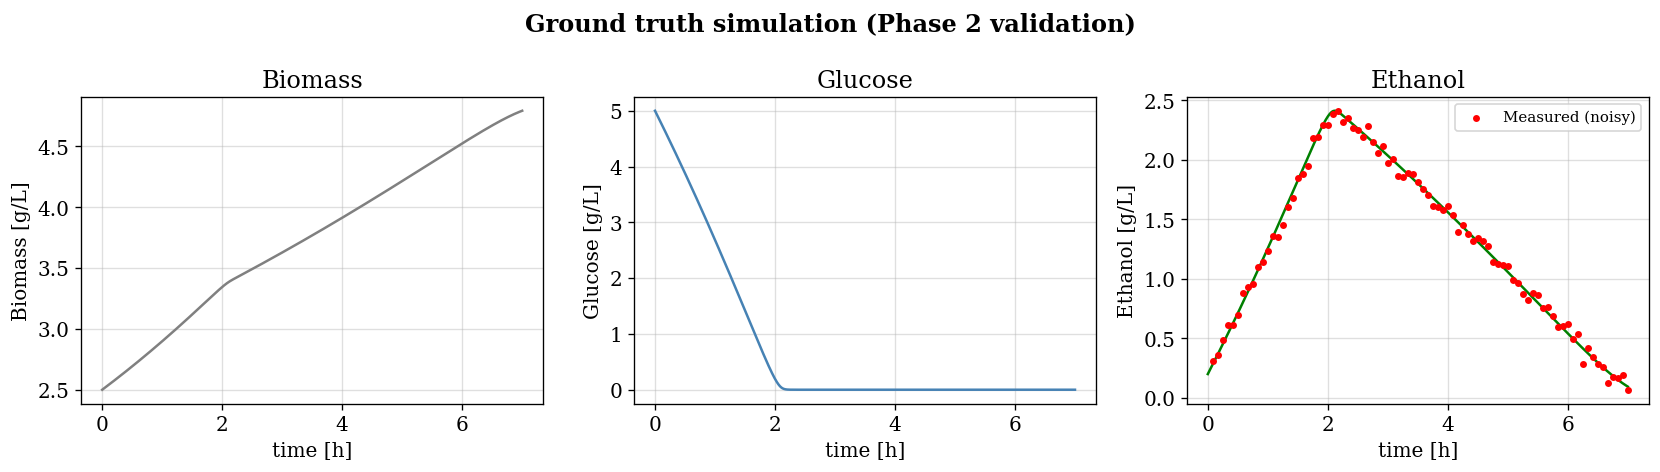


Diauxic switch visible at ~2h: glucose depletes, ethanol peaks, then consumed.


In [7]:
# ── Simulation settings ──────────────────────────────────────────────────
T_END   = 7.0    # [h]  total simulation time (paper runs ~6-7 hours)
DT_MEAS = 5/60   # [h]  measurement interval = 5 minutes converted to hours
NOISE_STD = 0.05 # [g/L] standard deviation of sensor noise on ethanol

# ── Run true process (dense time grid for plotting) ───────────────────────
t_dense = np.linspace(0, T_END, 2000)

sol_true = solve_ivp(
    fun=process_model,
    t_span=(0, T_END),
    y0=x0,
    t_eval=t_dense,
    method='RK45',
    rtol=1e-6,
    atol=1e-9
)

# Extract true trajectories
X_true      = sol_true.y[0]   # true biomass
G_true      = sol_true.y[1]   # true glucose
E_true      = sol_true.y[2]   # true ethanol
muG_true    = sol_true.y[3]   # true mu_max_G (constant in true model)
muE_true    = sol_true.y[4]   # true mu_max_E (constant in true model)
t_true      = sol_true.t

print(f"True simulation: {len(t_true)} time points over {T_END}h")
print(f"Final biomass:  {X_true[-1]:.3f} g/L")
print(f"Final glucose:  {G_true[-1]:.3f} g/L  (should be ~0)")
print(f"Final ethanol:  {E_true[-1]:.3f} g/L  (should be ~0)")

# ── Generate measurement times (every 5 min) ─────────────────────────────
t_meas = np.arange(DT_MEAS, T_END + DT_MEAS, DT_MEAS)

# ── Sample true ethanol at measurement times ──────────────────────────────
E_true_at_meas = np.interp(t_meas, t_true, E_true)

# ── Add Gaussian noise to simulate sensor ────────────────────────────────
np.random.seed(42)   # for reproducibility
noise = np.random.normal(0, NOISE_STD, len(t_meas))
E_measured = np.maximum(E_true_at_meas + noise, 0)   # clamp to >= 0

print(f"\nMeasurement times: {len(t_meas)} points, every {DT_MEAS*60:.0f} minutes")
print(f"Sensor noise std: {NOISE_STD} g/L")

# ── Quick preview plot ────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(14, 4))
fig.suptitle("Ground truth simulation (Phase 2 validation)", fontweight='bold')

for ax, y, label, color in zip(
    axes,
    [X_true, G_true, E_true],
    ['Biomass [g/L]', 'Glucose [g/L]', 'Ethanol [g/L]'],
    ['gray', 'steelblue', 'green']
):
    ax.plot(t_true, y, color=color, lw=1.5)
    ax.set_xlabel('time [h]')
    ax.set_ylabel(label)
    ax.set_title(label.split(' ')[0])

# Mark diauxic switch on ethanol plot
ax_e = axes[2]
ax_e.scatter(t_meas, E_measured, s=10, color='red', zorder=5, label='Measured (noisy)')
ax_e.legend(fontsize=9)

plt.tight_layout()
plt.savefig('figures/phase2_ground_truth.png', dpi=120, bbox_inches='tight')
plt.show()
print("\nDiauxic switch visible at ~2h: glucose depletes, ethanol peaks, then consumed.")


## Module 5 — EKF: Combined ODE System (State + Covariance)
In the continuous-discrete EKF, both the state x and the covariance P
are integrated simultaneously between measurements.

The covariance ODE is (Equation 11):
**dP/dt = F·P + P·Fᵀ + Q**

We pack everything into one 30-element vector:
- Elements 0–4: state [X, G, E, μmax,G, μmax,E]
- Elements 5–29: covariance P flattened (5×5 = 25 elements)

This is the equivalent of MATLAB's `OdeSys = matlabFunction([dS(:); dP(:)], ...)`


In [8]:
def combined_ode(t, combined_state):
    """
    Combined ODE for simultaneous integration of state x and covariance P.
    
    Input:  30-element vector [x (5 elements); P flattened (25 elements)]
    Output: 30-element derivative vector [dx/dt; dP/dt flattened]
    """
    # ── Unpack the combined state vector ──────────────────────────────────
    x = combined_state[:5]                        # state: [X, G, E, mu1, mu2]
    P = combined_state[5:].reshape(5, 5)          # covariance: 5x5 matrix
    
    # ── State derivatives: dx/dt = f(x) ──────────────────────────────────
    dx = np.array(process_model(t, x))
    
    # ── Covariance derivative: dP/dt = F·P + P·Fᵀ + Q ───────────────────
    F = compute_jacobian(x)                       # linearize at current state
    dP = F @ P + P @ F.T + Q                     # Equation 11
    
    # ── Pack everything back into one 30-element vector ───────────────────
    return np.concatenate([dx, dP.flatten()])


# ── Initial combined vector ───────────────────────────────────────────────
combined_init = np.concatenate([x0, P0.flatten()])
print(f"Combined initial vector length: {len(combined_init)}")
print(f"  First 5 (state):      {combined_init[:5]}")
print(f"  Next 25 (P diagonal): {np.diag(P0)}")


Combined initial vector length: 30
  First 5 (state):      [2.5  5.   0.2  0.15 0.08]
  Next 25 (P diagonal): [0.1  0.02 0.02 0.2  0.02]


## Module 5 (continued) — EKF Main Loop
This is the core of the implementation — equivalent to the MATLAB `for` loop.

**Each iteration:**
1. **Predict**: integrate 30 ODEs from previous measurement time to current
2. **Extract**: get predicted state PS and covariance P at measurement time
3. **Gain**: compute Kalman gain K = P·Hᵀ·(H·P·Hᵀ + R)⁻¹
4. **Correct**: filtered state FS = PS + K·(measurement − predicted ethanol)
5. **Update P**: Pflt = (I − K·H)·P·(I − K·H)ᵀ + K·R·Kᵀ (Joseph form — numerically stable)
6. **Store**: save results, prepare for next iteration


In [9]:
# ── Storage for results ───────────────────────────────────────────────────
filtered_states  = []    # filtered state at each measurement time
predicted_states = []    # all predicted states between measurements  
all_times        = []    # all time points (for plotting)

# ── Identity matrix (used in Joseph form covariance update) ───────────────
I5 = np.eye(5)

# ── Initialize ────────────────────────────────────────────────────────────
init_combined = np.concatenate([x0, P0.flatten()])
t_prev = 0.0

print("Starting EKF loop...")
print(f"Processing {len(t_meas)} measurements...")

# ── Main EKF loop — one iteration per ethanol measurement ─────────────────
for i, (t_now, z) in enumerate(zip(t_meas, E_measured)):

    # ── PREDICTION STEP ───────────────────────────────────────────────────
    # Integrate all 30 equations from t_prev to t_now
    sol = solve_ivp(
        fun=combined_ode,
        t_span=(t_prev, t_now),
        y0=init_combined,
        rtol=1e-6,
        atol=1e-9,
        dense_output=False
    )

    # Extract predicted state and covariance at measurement time
    PS = sol.y[:5, -1]                          # predicted state (5 elements)
    P  = sol.y[5:, -1].reshape(5, 5)           # predicted covariance (5x5)

    # Store predicted trajectory for plotting
    all_times.append(sol.t)
    predicted_states.append(sol.y[:5, :].T)    # shape (n_steps, 5)

    # ── CORRECTION STEP ───────────────────────────────────────────────────
    # Kalman gain: K = P·Hᵀ·(H·P·Hᵀ + R)⁻¹
    S  = H @ P @ H.T + R                       # innovation covariance (1x1)
    K  = P @ H.T @ np.linalg.inv(S)            # Kalman gain (5x1)

    # Innovation (residual): measured ethanol − predicted ethanol
    innovation = z - PS[2]                      # PS[2] is predicted ethanol

    # Corrected state
    FS = PS + (K @ [[innovation]]).flatten()    # filtered state (5 elements)

    # Covariance update — Joseph form (numerically stable)
    IKH  = I5 - K @ H
    Pflt = IKH @ P @ IKH.T + K @ R @ K.T

    # ── Store filtered state ──────────────────────────────────────────────
    filtered_states.append(FS.copy())

    # ── Prepare for next iteration ────────────────────────────────────────
    init_combined = np.concatenate([FS, Pflt.flatten()])
    t_prev = t_now

    # Progress indicator
    if (i + 1) % 20 == 0:
        print(f"  Step {i+1}/{len(t_meas)} — t={t_now:.2f}h | "
              f"X={FS[0]:.2f} G={FS[1]:.2f} E={FS[2]:.2f}")

# ── Convert to arrays ─────────────────────────────────────────────────────
filtered_states  = np.array(filtered_states)       # shape (n_meas, 5)
all_times_flat   = np.concatenate(all_times)        # all time points
pred_states_flat = np.vstack(predicted_states)      # all predicted states

print(f"\nEKF loop complete.")
print(f"  Filtered states shape:  {filtered_states.shape}")
print(f"  Predicted states shape: {pred_states_flat.shape}")


Starting EKF loop...
Processing 84 measurements...
  Step 20/84 — t=1.67h | X=3.17 G=1.14 E=1.97
  Step 40/84 — t=3.33h | X=3.75 G=0.00 E=1.84
  Step 60/84 — t=5.00h | X=4.21 G=0.00 E=1.07
  Step 80/84 — t=6.67h | X=4.72 G=-0.00 E=0.21

EKF loop complete.
  Filtered states shape:  (84, 5)
  Predicted states shape: (378, 5)


## Module 6 — Results: Reproduce Figure 4
Plot the EKF estimates alongside the ground truth — equivalent to Figure 4 from the paper.

- **Solid lines**: EKF Kalman estimates (predicted trajectories)
- **Dots**: "offline" ground truth values (sampled from our simulation)
- **Red crosses**: noisy ethanol measurements fed to the EKF


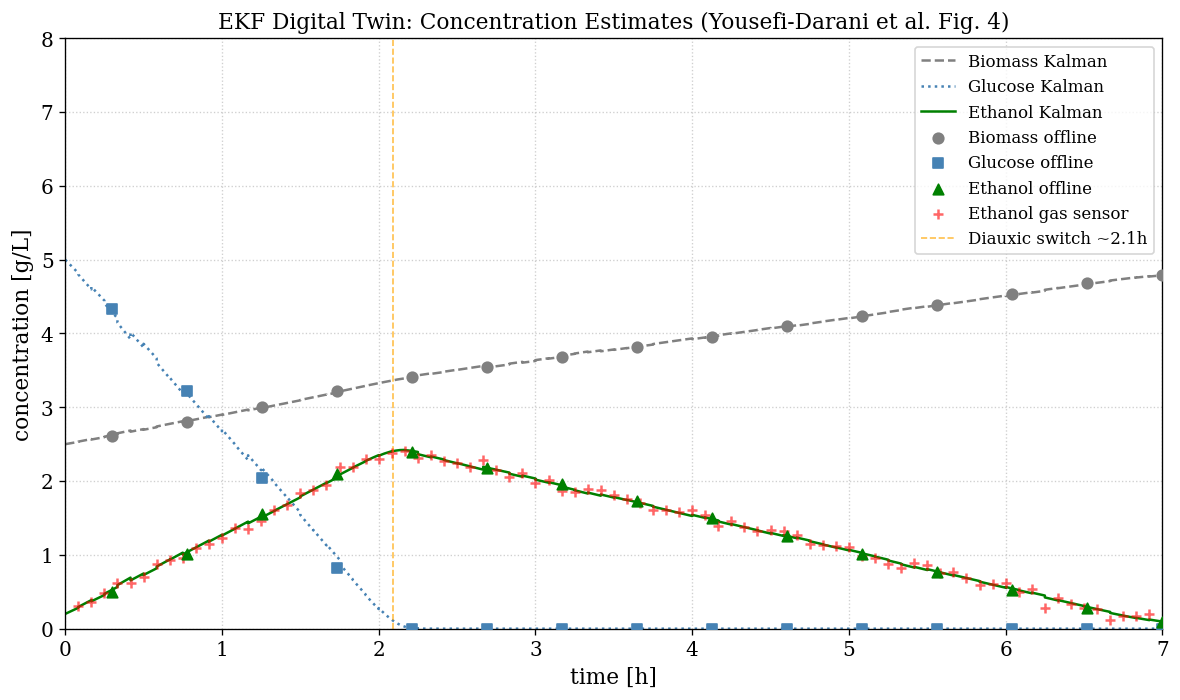

Figure saved as fig4_reproduction.png


In [10]:
# ── Sample "offline" ground truth at sparse time points (like lab samples) ─
t_offline = np.linspace(0.3, T_END, 15)   # ~15 offline samples
X_offline  = np.interp(t_offline, t_true, X_true)
G_offline  = np.interp(t_offline, t_true, G_true)
E_offline  = np.interp(t_offline, t_true, E_true)

# ── Create Figure 4 equivalent ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 6))

# Predicted (Kalman) lines
ax.plot(all_times_flat, pred_states_flat[:, 0],
        'gray',  ls='--', lw=1.5, label='Biomass Kalman')
ax.plot(all_times_flat, pred_states_flat[:, 1],
        'steelblue', ls=':', lw=1.5, label='Glucose Kalman')
ax.plot(all_times_flat, pred_states_flat[:, 2],
        'green', ls='-',  lw=1.5, label='Ethanol Kalman')

# Offline measurements (ground truth samples — never fed to EKF)
ax.scatter(t_offline, X_offline, color='gray',      s=40, zorder=5, label='Biomass offline')
ax.scatter(t_offline, G_offline, color='steelblue', s=40, marker='s', zorder=5, label='Glucose offline')
ax.scatter(t_offline, E_offline, color='green',     s=40, marker='^', zorder=5, label='Ethanol offline')

# Ethanol gas sensor measurements (what the EKF actually received)
ax.scatter(t_meas, E_measured, color='red', marker='+', s=30,
           zorder=4, label='Ethanol gas sensor', alpha=0.6)

ax.set_xlabel('time [h]', fontsize=13)
ax.set_ylabel('concentration [g/L]', fontsize=13)
ax.set_title('EKF Digital Twin: Concentration Estimates (Yousefi-Darani et al. Fig. 4)', fontsize=13)
ax.set_ylim(0, 8)
ax.set_xlim(0, T_END)
ax.legend(fontsize=10, loc='upper right',
          facecolor=[0.9, 0.9, 1.0, 0.9])
ax.grid(True, linestyle=':', alpha=0.6)

# Mark the diauxic switch
diauxic_t = t_true[np.argmin(np.abs(G_true - 0.05))]
ax.axvline(diauxic_t, color='orange', ls='--', lw=1, alpha=0.7, label=f'Diauxic switch ~{diauxic_t:.1f}h')
ax.legend(fontsize=10, loc='upper right')

plt.tight_layout()
plt.savefig('figures/fig4_reproduction.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Figure saved as fig4_reproduction.png")


## Module 6 (continued) — Results: Reproduce Figure 6
Plot the estimated maximum growth rates μmax,G and μmax,E alongside
the actual growth rates μG and μE — equivalent to Figure 6 from the paper.

Remember: μmax and μ are NOT supposed to match.
- μmax = the biological speed limit (estimated by EKF)
- μ = the actual current speed (computed from Monod + current concentrations)


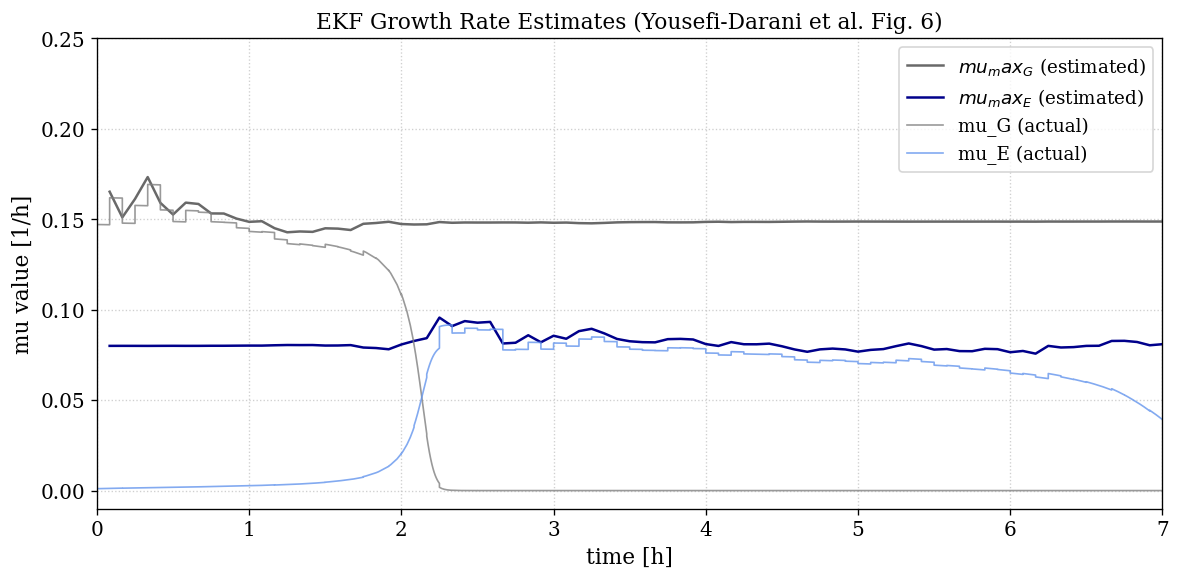

In [11]:
# ── Compute actual growth rates from predicted states ─────────────────────
mu_G_pred = np.zeros(len(all_times_flat))
mu_E_pred = np.zeros(len(all_times_flat))

for j, (state_j, t_j) in enumerate(zip(pred_states_flat, all_times_flat)):
    X_j, G_j, E_j, muG_max_j, muE_max_j = state_j
    mu_G_pred[j], mu_E_pred[j] = monod_rates(X_j, G_j, E_j, muG_max_j, muE_max_j)

# ── Create Figure 6 equivalent ───────────────────────────────────────────
fig, ax = plt.subplots(figsize=(10, 5))

# Maximum growth rates (estimated parameters — step-like due to 5-min updates)
ax.plot(t_meas, filtered_states[:, 3],
        color='dimgray',   lw=1.5, label=r'$mu_max_G$ (estimated)')
ax.plot(t_meas, filtered_states[:, 4],
        color='darkblue',  lw=1.5, label=r'$mu_max_E$ (estimated)')

# Actual growth rates (computed from Monod)
ax.plot(all_times_flat, mu_G_pred,
        color='gray', lw=1.0, alpha=0.8, label=r'mu_G (actual)')
ax.plot(all_times_flat, mu_E_pred,
        color='cornflowerblue', lw=1.0, alpha=0.8, label=r'mu_E (actual)')

ax.set_xlabel('time [h]', fontsize=13)
ax.set_ylabel('mu value [1/h]', fontsize=13)
ax.set_title('EKF Growth Rate Estimates (Yousefi-Darani et al. Fig. 6)', fontsize=13)
ax.set_xlim(0, T_END)
ax.set_ylim(-0.01, 0.25)
ax.legend(fontsize=11)
ax.grid(True, linestyle=':', alpha=0.6)

plt.tight_layout()
plt.savefig('figures/fig6_reproduction.png', dpi=150, bbox_inches='tight')
plt.show()


## Module 7 — Error Metrics
Compute RMSEP and R² to quantify how well the EKF estimates match the ground truth.
These are the same metrics reported in the paper (Table 5).

Target values from paper:
- Glucose RMSEP: 0.12 g/L
- Ethanol RMSEP: 0.14 g/L
- Biomass RMSEP: 0.12 g/L


In [12]:
# ── Interpolate EKF estimates at offline sample times ─────────────────────
X_ekf_at_offline  = np.interp(t_offline, t_meas, filtered_states[:, 0])
G_ekf_at_offline  = np.interp(t_offline, t_meas, filtered_states[:, 1])
E_ekf_at_offline  = np.interp(t_offline, t_meas, filtered_states[:, 2])

true_vals = np.column_stack([X_offline, G_offline, E_offline])
ekf_vals  = np.column_stack([X_ekf_at_offline, G_ekf_at_offline, E_ekf_at_offline])

# ── Compute metrics ───────────────────────────────────────────────────────
labels = ['Biomass', 'Glucose', 'Ethanol']
print("=" * 55)
print(f"{'Metric':<15} {'Biomass':>12} {'Glucose':>12} {'Ethanol':>12}")
print("=" * 55)

for metric_name, metric_fn in [
    ('RMSEP [g/L]', lambda t, p: np.sqrt(np.mean((t - p)**2))),
    ('R²',          lambda t, p: 1 - np.sum((t-p)**2)/np.sum((t-np.mean(t))**2)),
    ('Max error',   lambda t, p: np.max(np.abs(t - p))),
]:
    vals = [metric_fn(true_vals[:, i], ekf_vals[:, i]) for i in range(3)]
    print(f"{metric_name:<15} {vals[0]:>12.4f} {vals[1]:>12.4f} {vals[2]:>12.4f}")

print("=" * 55)
print("\nPaper target values (Table 5):")
print("  Glucose RMSEP: 0.12 g/L")
print("  Ethanol RMSEP: 0.14 g/L")
print("  Biomass RMSEP: 0.12 g/L")


Metric               Biomass      Glucose      Ethanol
RMSEP [g/L]           0.0122       0.0496       0.0220
R²                    0.9997       0.9986       0.9990
Max error             0.0238       0.1265       0.0404

Paper target values (Table 5):
  Glucose RMSEP: 0.12 g/L
  Ethanol RMSEP: 0.14 g/L
  Biomass RMSEP: 0.12 g/L


## H1a — Sensor Noise Robustness

### Research question
At what noise level does the EKF estimation quality degrade 
unacceptably? How does RMSEP change as the ethanol sensor 
becomes progressively noisier?

### Hypothesis
RMSEP increases with noise level. At low noise the EKF 
compensates effectively through the correction step. Beyond 
a critical noise threshold, the Kalman gain over-corrects 
and estimation quality degrades rapidly.

### Method
The EKF is run 7 times with increasing NOISE_STD values:
[0.01, 0.05, 0.1, 0.2, 0.5, 1.0, 2.0] g/L

NOISE_STD = 0.05 g/L is the baseline value from v1.0.

For each noise level:
- Generate noisy ethanol measurements
- Run the full EKF loop
- Compute RMSEP for biomass, glucose and ethanol
- Compare against offline ground truth

### Expected result
A curve showing RMSEP vs noise level — flat at low noise, 
rising steeply after a critical threshold. The threshold 
identifies the practical noise limit of this EKF configuration.

### Note on R
In this experiment once NOISE_STD changes but R stays fixed at 0.1 
(the value from the baseline). This is intentional — it tests 
what happens when the filter's assumed noise model does not 
match the real sensor noise. A second sub-experiment could 
then test what happens when R is updated to match NOISE_STD².

In [13]:
# ── H1a: Sensor Noise Robustness — with Kalman parameter monitoring ───────

import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# ── Noise levels to test ──────────────────────────────────────────────────
noise_levels = [0.01, 0.05, 0.1, 0.2, 0.5, 1.0, 2.0]
baseline_idx = 1   # NOISE_STD=0.05 is the baseline from v1.0

# ── Storage — RMSEP ───────────────────────────────────────────────────────
results = {
    'noise':   noise_levels,
    'rmsep_X': [], 'rmsep_G': [], 'rmsep_E': [],
}

# ── Storage — Kalman monitoring ───────────────────────────────────────────
monitoring_fixed = {
    'K0_mean':        [],   # mean Kalman gain for biomass across all steps
    'K2_mean':        [],   # mean Kalman gain for ethanol across all steps
    'P_final_diag':   [],   # P diagonal at t=7h (final uncertainty)
    'innov_var':      [],   # actual variance of innovations across 84 steps
    'innov_expected': [],   # expected innovation variance: H·P·Hᵀ + R
}

# ── Offline reference points ──────────────────────────────────────────────
t_offline = np.linspace(0.3, T_END, 15)
X_offline  = np.interp(t_offline, t_true, X_true)
G_offline  = np.interp(t_offline, t_true, G_true)
E_offline  = np.interp(t_offline, t_true, E_true)

print("Running H1a experiment with Kalman monitoring...")
print(f"{'NOISE_STD':>12} {'RMSEP_X':>10} {'RMSEP_G':>10} "
      f"{'RMSEP_E':>10} {'K0_mean':>10} {'K2_mean':>10}")
print("-" * 65)

# ── Main experiment loop ──────────────────────────────────────────────────
for noise_std in noise_levels:

    # Generate noisy measurements — R stays fixed at 0.1
    np.random.seed(42)
    noise        = np.random.normal(0, noise_std, len(t_meas))
    E_meas_noisy = np.maximum(E_true_at_meas + noise, 0)

    # Per-run storage
    filtered      = []
    K0_steps      = []   # Kalman gain for biomass at each step
    K2_steps      = []   # Kalman gain for ethanol at each step
    innov_steps   = []   # innovation at each step
    innov_exp_steps = [] # expected innovation variance at each step
    P_last        = None

    P_diag_fixed = []
    P_diag_matched = []

    init_h4a   = np.concatenate([x0, P0.flatten()])
    t_prev_h4a = 0.0

    for t_now, z in zip(t_meas, E_meas_noisy):

        # Prediction
        sol = solve_ivp(
            combined_ode,
            t_span=(t_prev_h4a, t_now),
            y0=init_h4a,
            method='RK45', rtol=1e-6, atol=1e-9,
            dense_output=False
        )
        PS   = sol.y[:5, -1]
        P_h4 = sol.y[5:, -1].reshape(5, 5)

        # Innovation
        innovation = z - PS[2]

        # Kalman gain
        S_h4 = H @ P_h4 @ H.T + R
        K_h4 = P_h4 @ H.T @ np.linalg.inv(S_h4)

        # Correction
        FS   = PS + (K_h4 @ [[innovation]]).flatten()
        IKH  = I5 - K_h4 @ H
        Pflt = IKH @ P_h4 @ IKH.T + K_h4 @ R @ K_h4.T
        P_diag_fixed.append(np.diag(Pflt).copy())
        eigenvalues = np.linalg.eigvals(Pflt)
        if np.any(eigenvalues <= 0):
            print(f"P lost positive definiteness at step {i}, t={t_now:.2f}h")
            print(f"Eigenvalues: {eigenvalues}")

        # Collect monitoring values
        K0_steps.append(abs(K_h4[0, 0]))       # biomass gain
        K2_steps.append(abs(K_h4[2, 0]))       # ethanol gain
        innov_steps.append(innovation)
        innov_exp_steps.append(float(S_h4))    # H·P·Hᵀ + R

        filtered.append(FS.copy())
        P_last     = Pflt.copy()
        init_h4a   = np.concatenate([FS, Pflt.flatten()])
        t_prev_h4a = t_now

    filtered = np.array(filtered)

    # RMSEP
    X_ekf   = np.interp(t_offline, t_meas, filtered[:, 0])
    G_ekf   = np.interp(t_offline, t_meas, filtered[:, 1])
    E_ekf   = np.interp(t_offline, t_meas, filtered[:, 2])
    rmsep_X = np.sqrt(np.mean((X_ekf - X_offline)**2))
    rmsep_G = np.sqrt(np.mean((G_ekf - G_offline)**2))
    rmsep_E = np.sqrt(np.mean((E_ekf - E_offline)**2))

    # Store results
    results['rmsep_X'].append(rmsep_X)
    results['rmsep_G'].append(rmsep_G)
    results['rmsep_E'].append(rmsep_E)

    # Store monitoring
    monitoring_fixed['K0_mean'].append(np.mean(K0_steps))
    monitoring_fixed['K2_mean'].append(np.mean(K2_steps))
    monitoring_fixed['P_final_diag'].append(np.diag(P_last).copy())
    monitoring_fixed['innov_var'].append(np.var(innov_steps))
    monitoring_fixed['innov_expected'].append(np.mean(innov_exp_steps))

    marker = " ← baseline" if noise_std == 0.05 else ""
    print(f"{noise_std:>12.2f} {rmsep_X:>10.4f} {rmsep_G:>10.4f} "
          f"{rmsep_E:>10.4f} {np.mean(K0_steps):>10.4f} "
          f"{np.mean(K2_steps):>10.4f}{marker}")

print("\nDone.")

Running H1a experiment with Kalman monitoring...
   NOISE_STD    RMSEP_X    RMSEP_G    RMSEP_E    K0_mean    K2_mean
-----------------------------------------------------------------
        0.01     0.0025     0.0100     0.0044     0.1249     0.2265
        0.05     0.0122     0.0496     0.0220     0.1237     0.2270 ← baseline
        0.10     0.0245     0.0990     0.0442     0.1221     0.2275
        0.20     0.0514     0.1992     0.0906     0.1190     0.2298


/var/folders/29/tpmz3bt97k7_t01r5r28cqb40000gn/T/ipykernel_68062/2549831111.py:93: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  innov_exp_steps.append(float(S_h4))    # H·P·Hᵀ + R


        0.50     0.3986     0.9393     0.2791     0.2010     0.3156
        1.00     0.9231     2.1603     0.4072     0.0651     0.2156
        2.00     0.6341     1.3574     1.4802     0.0377     0.0689

Done.


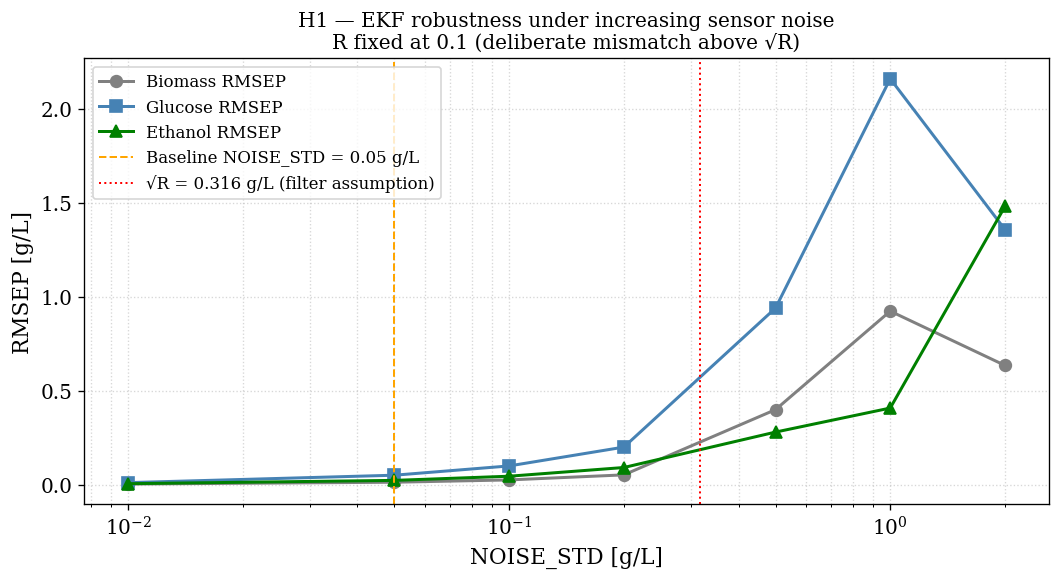

Interpretation:
  Baseline (0.05 g/L) — X: 0.0122  G: 0.0496  E: 0.0220 g/L
  Worst   (2.00 g/L) — X: 0.6341  G: 1.3574  E: 1.4802 g/L

  Degradation factor X: 51.9x
  Degradation factor G: 27.4x
  Degradation factor E: 67.2x


In [14]:
# ── H1a: Plot RMSEP vs Noise Level ───────────────────────────────────────

fig, ax = plt.subplots(figsize=(9, 5))

ax.plot(noise_levels, results['rmsep_X'],
        'o-', color='gray',      lw=1.8, ms=7, label='Biomass RMSEP')
ax.plot(noise_levels, results['rmsep_G'],
        's-', color='steelblue', lw=1.8, ms=7, label='Glucose RMSEP')
ax.plot(noise_levels, results['rmsep_E'],
        '^-', color='green',     lw=1.8, ms=7, label='Ethanol RMSEP')

# Mark baseline
ax.axvline(0.05, color='orange', ls='--', lw=1.2,
           label='Baseline NOISE_STD = 0.05 g/L')

# Mark R value
ax.axvline(np.sqrt(0.1), color='red', ls=':', lw=1.2,
           label=f'√R = {np.sqrt(0.1):.3f} g/L (filter assumption)')

ax.set_xscale('log')
ax.set_xlabel('NOISE_STD [g/L]', fontsize=13)
ax.set_ylabel('RMSEP [g/L]', fontsize=13)
ax.set_title('H1 — EKF robustness under increasing sensor noise\n'
             'R fixed at 0.1 (deliberate mismatch above √R)', fontsize=12)
ax.legend(fontsize=10)
ax.grid(True, which='both', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.savefig('figures/H1_noise_robustness.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Summary interpretation ────────────────────────────────────────────────
print("Interpretation:")
print(f"  Baseline (0.05 g/L) — "
      f"X: {results['rmsep_X'][1]:.4f}  "
      f"G: {results['rmsep_G'][1]:.4f}  "
      f"E: {results['rmsep_E'][1]:.4f} g/L")
print(f"  Worst   (2.00 g/L) — "
      f"X: {results['rmsep_X'][-1]:.4f}  "
      f"G: {results['rmsep_G'][-1]:.4f}  "
      f"E: {results['rmsep_E'][-1]:.4f} g/L")
print(f"\n  Degradation factor X: "
      f"{results['rmsep_X'][-1]/results['rmsep_X'][1]:.1f}x")
print(f"  Degradation factor G: "
      f"{results['rmsep_G'][-1]/results['rmsep_G'][1]:.1f}x")
print(f"  Degradation factor E: "
      f"{results['rmsep_E'][-1]/results['rmsep_E'][1]:.1f}x")

In [15]:
# ── H1b Part 2: Matched R experiment ─────────────────────────────────────

# ── Storage — matched R results ───────────────────────────────────────────
R_levels = [0.001, 0.009, 0.01, 0.02, 0.05, 0.1, 0.2]

results_adaptive = {
    'noise':           noise_levels,
    'rmsep_X_adaptive': [],
    'rmsep_G_adaptive': [],
    'rmsep_E_adaptive': [],
}

monitoring_adaptive = {
    'K0_mean':        [],
    'K2_mean':        [],
    'P_final_diag':   [],
    'innov_var':      [],
    'innov_expected': [],
}

print("Running H4a Part 2 — Matched R experiment...")
print(f"{'NOISE_STD':>12} {'R_adaptive':>12} {'RMSEP_X':>10} "
      f"{'RMSEP_G':>10} {'RMSEP_E':>10}")
print("-" * 58)

# ── Main loop ─────────────────────────────────────────────────────────────
for noise_std in noise_levels:

    # R matched to real noise
    R_adaptive = np.array([[noise_std]])
    i = 1

    # Generate noisy measurements — same seed for fair comparison
    np.random.seed(42)
    noise        = np.random.normal(0, noise_std, len(t_meas))
    E_meas_noisy = np.maximum(E_true_at_meas + noise, 0)

    # Per-run storage
    filtered        = []
    K0_steps        = []
    K2_steps        = []
    innov_steps     = []
    innov_exp_steps = []
    P_last          = None

    init_h4a   = np.concatenate([x0, P0.flatten()])
    t_prev_h4a = 0.0

    for t_now, z in zip(t_meas, E_meas_noisy):

        # Prediction
        sol = solve_ivp(
            combined_ode,
            t_span=(t_prev_h4a, t_now),
            y0=init_h4a,
            method='RK45', rtol=1e-6, atol=1e-9,
            dense_output=False
        )
        PS   = sol.y[:5, -1]
        P_h4 = sol.y[5:, -1].reshape(5, 5)

        # Innovation
        innovation = z - PS[2]

        # Kalman gain — using R_adaptive
        S_h4 = H @ P_h4 @ H.T + R_adaptive
        K_h4 = P_h4 @ H.T @ np.linalg.inv(S_h4)

        # Correction
        FS   = PS + (K_h4 @ [[innovation]]).flatten()
        IKH  = I5 - K_h4 @ H
        Pflt = IKH @ P_h4 @ IKH.T + K_h4 @ R_adaptive @ K_h4.T
        i = i + 0.3
        #R_adaptive = np.array([[noise_std**i]])

        # Collect monitoring
        K0_steps.append(abs(K_h4[0, 0]))
        K2_steps.append(abs(K_h4[2, 0]))
        innov_steps.append(innovation)
        innov_exp_steps.append(float(S_h4))

        filtered.append(FS.copy())
        P_last     = Pflt.copy()
        init_h4a   = np.concatenate([FS, Pflt.flatten()])
        t_prev_h4a = t_now

    filtered = np.array(filtered)

    # RMSEP
    X_ekf   = np.interp(t_offline, t_meas, filtered[:, 0])
    G_ekf   = np.interp(t_offline, t_meas, filtered[:, 1])
    E_ekf   = np.interp(t_offline, t_meas, filtered[:, 2])
    rmsep_X = np.sqrt(np.mean((X_ekf - X_offline)**2))
    rmsep_G = np.sqrt(np.mean((G_ekf - G_offline)**2))
    rmsep_E = np.sqrt(np.mean((E_ekf - E_offline)**2))

    # Store results
    results_adaptive['rmsep_X_adaptive'].append(rmsep_X)
    results_adaptive['rmsep_G_adaptive'].append(rmsep_G)
    results_adaptive['rmsep_E_adaptive'].append(rmsep_E)

    # Store monitoring
    monitoring_adaptive['K0_mean'].append(np.mean(K0_steps))
    monitoring_adaptive['K2_mean'].append(np.mean(K2_steps))
    monitoring_adaptive['P_final_diag'].append(np.diag(P_last).copy())
    monitoring_adaptive['innov_var'].append(np.var(innov_steps))
    monitoring_adaptive['innov_expected'].append(np.mean(innov_exp_steps))

    marker = " ← baseline" if noise_std == 0.05 else ""
    print(f"{noise_std:>12.2f} {float(R_adaptive):>12.4f} "
          f"{rmsep_X:>10.4f} {rmsep_G:>10.4f} {rmsep_E:>10.4f}{marker}")

print("\nDone.")

Running H4a Part 2 — Matched R experiment...
   NOISE_STD   R_adaptive    RMSEP_X    RMSEP_G    RMSEP_E
----------------------------------------------------------
        0.01       0.0100     0.0037     0.0135     0.0051
        0.05       0.0500     0.0132     0.0565     0.0229 ← baseline
        0.10       0.1000     0.0245     0.0990     0.0442
        0.20       0.2000     0.0477     0.1725     0.0858
        0.50       0.5000     0.1163     0.3783     0.2094
        1.00       1.0000     0.1994     0.6478     0.3556


/var/folders/29/tpmz3bt97k7_t01r5r28cqb40000gn/T/ipykernel_68062/4140295248.py:80: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  innov_exp_steps.append(float(S_h4))
/var/folders/29/tpmz3bt97k7_t01r5r28cqb40000gn/T/ipykernel_68062/4140295248.py:110: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  print(f"{noise_std:>12.2f} {float(R_adaptive):>12.4f} "


        2.00       2.0000     0.5562     1.1008     0.8049

Done.


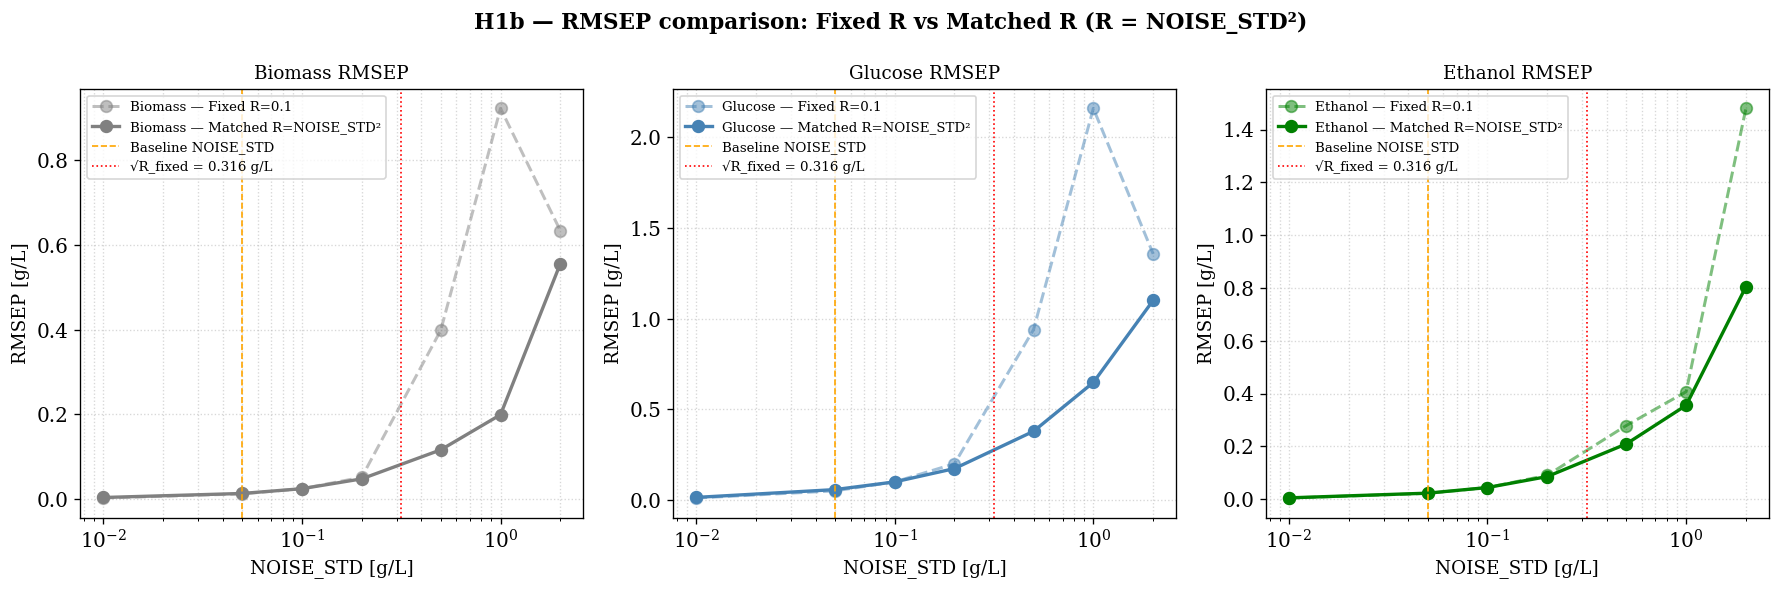

RMSEP comparison — Fixed R vs Matched R:
   NOISE_STD    X_fixed    X_match    G_fixed    G_match    E_fixed    E_match
---------------------------------------------------------------------------
        0.01     0.0025     0.0037     0.0100     0.0135     0.0044     0.0051
        0.05     0.0122     0.0132     0.0496     0.0565     0.0220     0.0229 ← baseline
        0.10     0.0245     0.0245     0.0990     0.0990     0.0442     0.0442
        0.20     0.0514     0.0477     0.1992     0.1725     0.0906     0.0858
        0.50     0.3986     0.1163     0.9393     0.3783     0.2791     0.2094
        1.00     0.9231     0.1994     2.1603     0.6478     0.4072     0.3556
        2.00     0.6341     0.5562     1.3574     1.1008     1.4802     0.8049


In [16]:
# ── H1b Part 2: RMSEP Comparison — Fixed R vs Matched R ──────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('H1b — RMSEP comparison: Fixed R vs Matched R (R = NOISE_STD²)',
             fontsize=13, fontweight='bold')

variables = [
    ('rmsep_X', 'rmsep_X_adaptive', 'Biomass', 'gray'),
    ('rmsep_G', 'rmsep_G_adaptive', 'Glucose', 'steelblue'),
    ('rmsep_E', 'rmsep_E_adaptive', 'Ethanol', 'green'),
]

for ax, (fixed_key, adaptive_key, label, color) in zip(axes, variables):

    # Fixed R (from H4a)
    ax.plot(noise_levels, results[fixed_key],
            'o--', color=color, lw=1.8, ms=7, alpha=0.5,
            label=f'{label} — Fixed R=0.1')

    # Matched R (new results)
    ax.plot(noise_levels, results_adaptive[adaptive_key],
            'o-', color=color, lw=2.0, ms=7,
            label=f'{label} — Matched R=NOISE_STD²')

    # Reference lines
    ax.axvline(0.05, color='orange', ls='--', lw=1.0,
               label='Baseline NOISE_STD')
    ax.axvline(np.sqrt(0.1), color='red', ls=':', lw=1.0,
               label='√R_fixed = 0.316 g/L')

    ax.set_xscale('log')
    ax.set_xlabel('NOISE_STD [g/L]', fontsize=11)
    ax.set_ylabel('RMSEP [g/L]', fontsize=11)
    ax.set_title(f'{label} RMSEP', fontsize=11)
    ax.legend(fontsize=8)
    ax.grid(True, which='both', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.savefig('figures/H1_rmsep_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Numerical summary ─────────────────────────────────────────────────────
print("RMSEP comparison — Fixed R vs Matched R:")
print(f"{'NOISE_STD':>12} {'X_fixed':>10} {'X_match':>10} "
      f"{'G_fixed':>10} {'G_match':>10} "
      f"{'E_fixed':>10} {'E_match':>10}")
print("-" * 75)
for i, ns in enumerate(noise_levels):
    marker = " ← baseline" if ns == 0.05 else ""
    print(f"{ns:>12.2f} "
          f"{results['rmsep_X'][i]:>10.4f} "
          f"{results_adaptive['rmsep_X_adaptive'][i]:>10.4f} "
          f"{results['rmsep_G'][i]:>10.4f} "
          f"{results_adaptive['rmsep_G_adaptive'][i]:>10.4f} "
          f"{results['rmsep_E'][i]:>10.4f} "
          f"{results_adaptive['rmsep_E_adaptive'][i]:>10.4f}{marker}")

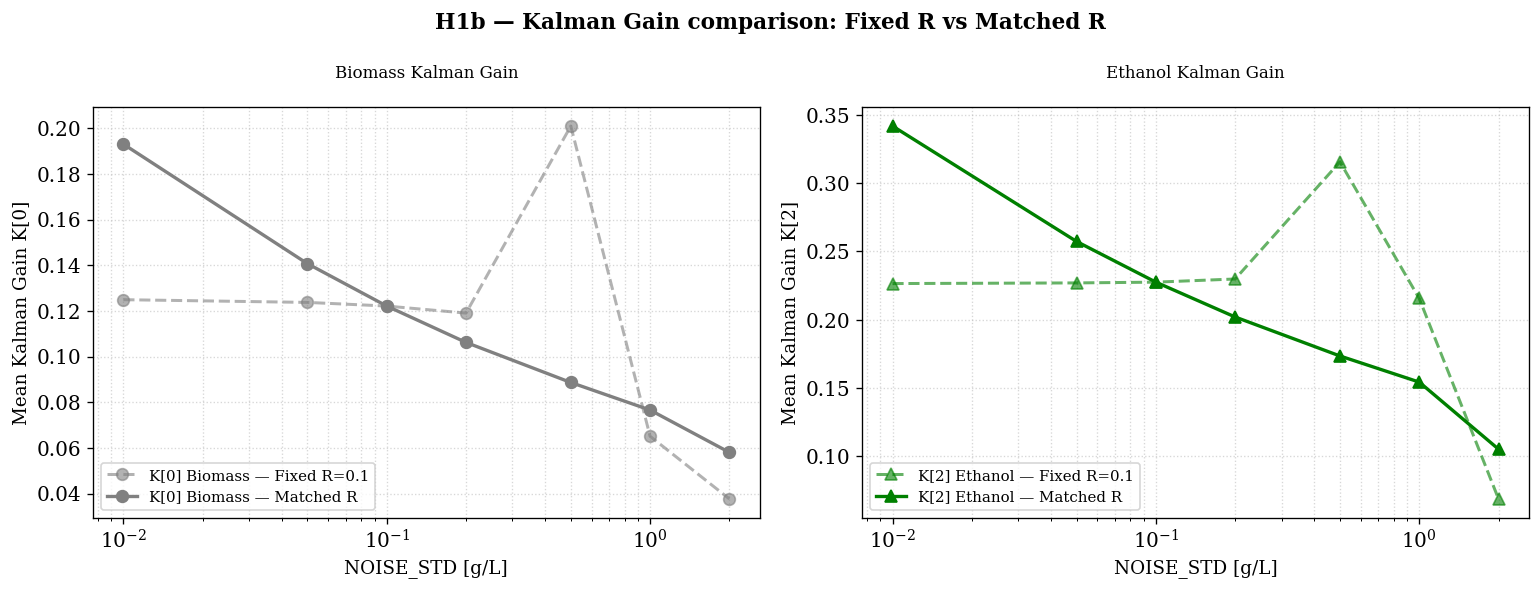

Kalman Gain comparison — Fixed R vs Matched R:
   NOISE_STD     K0_fixed     K0_match     K2_fixed     K2_match
----------------------------------------------------------------
        0.01       0.1249       0.1930       0.2265       0.3418
        0.05       0.1237       0.1407       0.2270       0.2573 ← baseline
        0.10       0.1221       0.1221       0.2275       0.2275
        0.20       0.1190       0.1062       0.2298       0.2020
        0.50       0.2010       0.0887       0.3156       0.1735
        1.00       0.0651       0.0766       0.2156       0.1544
        2.00       0.0377       0.0580       0.0689       0.1053


In [17]:
# ── H1b Part 2: Kalman Gain Comparison — Fixed R vs Matched R ────────────

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('H1b — Kalman Gain comparison: Fixed R vs Matched R',
             fontsize=13, fontweight='bold')

# ── Panel 1: K[0] Biomass gain ────────────────────────────────────────────
ax1 = axes[0]
ax1.plot(noise_levels, monitoring_fixed['K0_mean'],
         'o--', color='gray', lw=1.8, ms=7, alpha=0.6,
         label='K[0] Biomass — Fixed R=0.1')
ax1.plot(noise_levels, monitoring_adaptive['K0_mean'],
         'o-', color='gray', lw=2.0, ms=7,
         label='K[0] Biomass — Matched R')

#ax1.axvline(0.05, color='orange', ls='--', lw=1.0, label='Baseline')
#ax1.axvline(np.sqrt(0.1), color='red', ls=':', lw=1.0, label='√R_fixed')

ax1.set_xscale('log')
ax1.set_xlabel('NOISE_STD [g/L]', fontsize=11)
ax1.set_ylabel('Mean Kalman Gain K[0]', fontsize=11)
ax1.set_title('Biomass Kalman Gain\n'
              , fontsize=10)
ax1.legend(fontsize=9)
ax1.grid(True, which='both', linestyle=':', alpha=0.5)

# ── Panel 2: K[2] Ethanol gain ────────────────────────────────────────────
ax2 = axes[1]
ax2.plot(noise_levels, monitoring_fixed['K2_mean'],
         '^--', color='green', lw=1.8, ms=7, alpha=0.6,
         label='K[2] Ethanol — Fixed R=0.1')
ax2.plot(noise_levels, monitoring_adaptive['K2_mean'],
         '^-', color='green', lw=2.0, ms=7,
         label='K[2] Ethanol — Matched R')

#ax2.axvline(0.05, color='orange', ls='--', lw=1.0, label='Baseline')
#ax2.axvline(np.sqrt(0.1), color='red', ls=':', lw=1.0, label='√R_fixed')

ax2.set_xscale('log')
ax2.set_xlabel('NOISE_STD [g/L]', fontsize=11)
ax2.set_ylabel('Mean Kalman Gain K[2]', fontsize=11)
ax2.set_title('Ethanol Kalman Gain\n'
              , fontsize=10)
ax2.legend(fontsize=9)
ax2.grid(True, which='both', linestyle=':', alpha=0.5)

plt.tight_layout()
plt.savefig('figures/H1b_kalman_gain_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Numerical summary ─────────────────────────────────────────────────────
print("Kalman Gain comparison — Fixed R vs Matched R:")
print(f"{'NOISE_STD':>12} {'K0_fixed':>12} {'K0_match':>12} "
      f"{'K2_fixed':>12} {'K2_match':>12}")
print("-" * 64)
for i, ns in enumerate(noise_levels):
    marker = " ← baseline" if ns == 0.05 else ""
    print(f"{ns:>12.2f} "
          f"{monitoring_fixed['K0_mean'][i]:>12.4f} "
          f"{monitoring_adaptive['K0_mean'][i]:>12.4f} "
          f"{monitoring_fixed['K2_mean'][i]:>12.4f} "
          f"{monitoring_adaptive['K2_mean'][i]:>12.4f}{marker}")

In [18]:
print("R values used in fixed R experiment:")
print("R =", R)
print()
print("R_adaptive at each noise level:")
for ns in noise_levels:
    print(f"  NOISE_STD={ns:.2f} → R_adaptive = {ns**2:.6f}")

R values used in fixed R experiment:
R = [[0.1]]

R_adaptive at each noise level:
  NOISE_STD=0.01 → R_adaptive = 0.000100
  NOISE_STD=0.05 → R_adaptive = 0.002500
  NOISE_STD=0.10 → R_adaptive = 0.010000
  NOISE_STD=0.20 → R_adaptive = 0.040000
  NOISE_STD=0.50 → R_adaptive = 0.250000
  NOISE_STD=1.00 → R_adaptive = 1.000000
  NOISE_STD=2.00 → R_adaptive = 4.000000


## H2 — Sensor Drift Robustness

### Three scenarios

**H2-1 — Unknown drift, fixed R:**
The filter has no knowledge of the drift. R stays fixed at 0.1.
The drift accumulates silently and corrupts the estimates.
Residuals develop a systematic upward trend — the fault signature.

**H2-2 — Known drift, time-varying R(t):**
The filter knows the drift rate but models it as increased noise.
R grows over time: R(t) = (σ_noise + d·t)²
Result: filter increasingly ignores measurements — but drift 
already corrupted early corrections. Surprisingly ineffective.


### Drift rates tested
d = [0.0, 0.01, 0.05, 0.1, 0.2, 0.5] g/L per hour

At d=0.5: sensor reads 3.5 g/L too high at t=7h
— larger than the ethanol peak itself (~1.8 g/L)

### Mathematical model
z_k = E_true(t_k) + ε_k + d · t_k

H4b-1: innovation = z_k − H·x_k           (drift unmodelled)
H4b-2: R(t) = (σ + d·t)²                  (drift → noise)

### Key hypothesis
H4b-1 residuals show a linear trend — detectable as a fault.
H4b-2 performs worse than H4b-1 — inflating R is not the 
right response to systematic drift.


In [19]:
# ── H2a: Sensor Drift Robustness — three scenarios ───────────────────────

from scipy import stats

drift_rates   = [0.0, 0.01, 0.05, 0.1, 0.2, 0.5]
NOISE_STD_H2 = 0.05   # same baseline noise as v1.0

# ── Storage ───────────────────────────────────────────────────────────────
results_h2a = {
    'drift': drift_rates,
    # H2a-1: unknown drift, fixed R
    'rmsep_X_h1': [], 'rmsep_G_h1': [], 'rmsep_E_h1': [],
    'residuals_h1': [],
    # H2a-2: known drift, time-varying R
    'rmsep_X_h2': [], 'rmsep_G_h2': [], 'rmsep_E_h2': [],
    'residuals_h2': [],
}

# ── Offline reference ─────────────────────────────────────────────────────
t_offline = np.linspace(0.3, T_END, 15)
X_offline  = np.interp(t_offline, t_true, X_true)
G_offline  = np.interp(t_offline, t_true, G_true)
E_offline  = np.interp(t_offline, t_true, E_true)

print("Running H2a — three scenarios...")
print(f"\n{'Drift':>6} | "
      f"{'H1_X':>7} {'H1_G':>7} {'H1_E':>7} | "
      f"{'H2_X':>7} {'H2_G':>7} {'H2_E':>7} | "
      )
print("-" * 80)

for drift in drift_rates:

    # Generate drifting measurements — same for all three scenarios
    np.random.seed(42)
    noise_h2    = np.random.normal(0, NOISE_STD_H2, len(t_meas))
    drift_signal = drift * t_meas
    E_meas_drift = np.maximum(
        E_true_at_meas + noise_h2 + drift_signal, 0
    )

    # ── Three scenario definitions ────────────────────────────────────────
    def run_scenario(z_series, R_fn, drift_comp=0.0):
        """
        Run EKF for one scenario.
        z_series:   array of measurements (same drifting signal for all)
        R_fn:       function(t) → R matrix
        drift_comp: known drift rate to subtract from measurement [g/L/h]
        """
        filtered  = []
        residuals = []
        init_ekf  = np.concatenate([x0, P0.flatten()])
        t_prev    = 0.0

        for t_now, z in zip(t_meas, z_series):

            # Prediction
            sol = solve_ivp(
                combined_ode,
                t_span=(t_prev, t_now),
                y0=init_ekf,
                method='RK45', rtol=1e-6, atol=1e-9,
                dense_output=False
            )
            PS  = sol.y[:5, -1]
            P_k = sol.y[5:, -1].reshape(5, 5)

            # Drift compensation — subtract known drift before correction
            z_corrected = z - drift_comp * t_now
            innovation  = z_corrected - PS[2]
            residuals.append(innovation)

            # Kalman gain
            R_now = R_fn(t_now)
            S_k   = H @ P_k @ H.T + R_now
            K_k   = P_k @ H.T @ np.linalg.inv(S_k)

            # Correction
            FS   = PS + (K_k @ [[innovation]]).flatten()
            IKH  = I5 - K_k @ H
            Pflt = IKH @ P_k @ IKH.T + K_k @ R_now @ K_k.T

            filtered.append(FS.copy())
            init_ekf = np.concatenate([FS, Pflt.flatten()])
            t_prev   = t_now

        return np.array(filtered), residuals

    # ── Run all three scenarios ───────────────────────────────────────────

    # H2-1: unknown drift, fixed R, no compensation
    filt_h1, res_h1 = run_scenario(
        E_meas_drift,
        R_fn=lambda t: R,
        drift_comp=0.0
    )

    # H2-2: known drift, time-varying R, no compensation
    filt_h2, res_h2 = run_scenario(
        E_meas_drift,
        R_fn=lambda t: np.array([[(NOISE_STD_H2 + drift * t)**2]]),
        drift_comp=0.0
    )

 

    # ── Compute RMSEP for all three ───────────────────────────────────────
    def compute_rmsep(filtered):
        X_ekf = np.interp(t_offline, t_meas, filtered[:, 0])
        G_ekf = np.interp(t_offline, t_meas, filtered[:, 1])
        E_ekf = np.interp(t_offline, t_meas, filtered[:, 2])
        rX = np.sqrt(np.mean((X_ekf - X_offline)**2))
        rG = np.sqrt(np.mean((G_ekf - G_offline)**2))
        rE = np.sqrt(np.mean((E_ekf - E_offline)**2))
        return rX, rG, rE

    rX1, rG1, rE1 = compute_rmsep(filt_h1)
    rX2, rG2, rE2 = compute_rmsep(filt_h2)
    

    # Store results
    for key, vals in [
        ('h1', (rX1,rG1,rE1,res_h1)),
        ('h2', (rX2,rG2,rE2,res_h2)),
        
    ]:
        results_h2a[f'rmsep_X_{key}'].append(vals[0])
        results_h2a[f'rmsep_G_{key}'].append(vals[1])
        results_h2a[f'rmsep_E_{key}'].append(vals[2])
        results_h2a[f'residuals_{key}'].append(vals[3])

    marker = " ← baseline" if drift == 0.0 else ""
    print(f"{drift:>6.2f} | "
          f"{rX1:>7.4f} {rG1:>7.4f} {rE1:>7.4f} | "
          f"{rX2:>7.4f} {rG2:>7.4f} {rE2:>7.4f} | "
         )

print("\nDone.")

Running H2a — three scenarios...

 Drift |    H1_X    H1_G    H1_E |    H2_X    H2_G    H2_E | 
--------------------------------------------------------------------------------
  0.00 |  0.0122  0.0496  0.0220 |  0.0862  0.0664  0.0286 | 
  0.01 |  0.0239  0.0422  0.0449 |  0.0602  0.0566  0.0488 | 
  0.05 |  0.1022  0.0492  0.2092 |  0.1057  0.0427  0.2083 | 
  0.10 |  0.2067  0.1027  0.4229 |  0.2169  0.0915  0.4306 | 
  0.20 |  0.4209  0.2193  0.8522 |  0.5034  0.2175  0.9244 | 
  0.50 |  1.1607  0.4618  2.1357 |  1.4189  0.4766  2.4122 | 

Done.


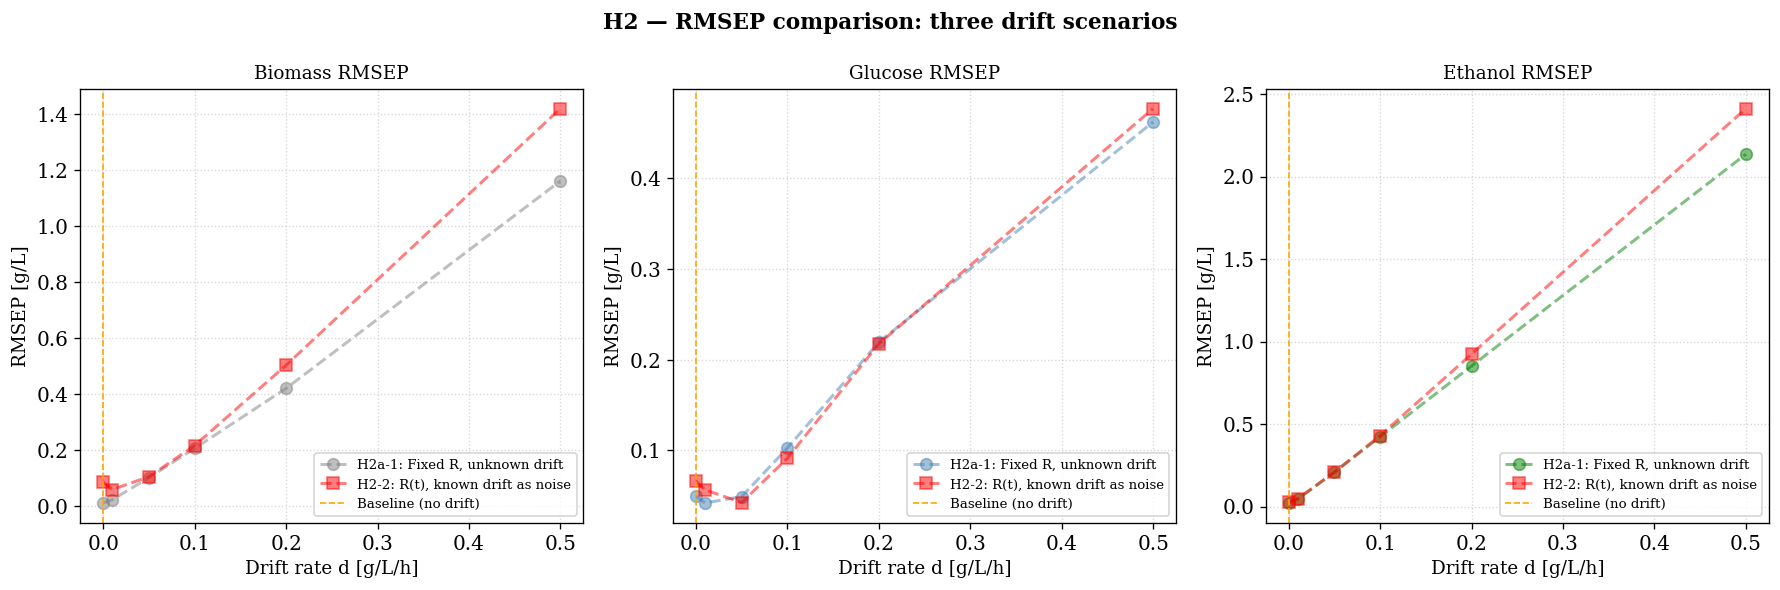

In [20]:
# ── H2a Plot 1: RMSEP comparison — all three scenarios ───────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('H2 — RMSEP comparison: three drift scenarios',
             fontsize=13, fontweight='bold')

variables = [
    ('rmsep_X_h1','rmsep_X_h2','rmsep_X_h3','Biomass','gray'),
    ('rmsep_G_h1','rmsep_G_h2','rmsep_G_h3','Glucose','steelblue'),
    ('rmsep_E_h1','rmsep_E_h2','rmsep_E_h3','Ethanol','green'),
]

for ax, (k1, k2, k3, label, color) in zip(axes, variables):
    ax.plot(drift_rates, results_h2a[k1],
            'o--', color=color, lw=1.8, ms=7, alpha=0.5,
            label='H2a-1: Fixed R, unknown drift')
    ax.plot(drift_rates, results_h2a[k2],
            's--', color='red', lw=1.8, ms=7, alpha=0.5,
            label='H2-2: R(t), known drift as noise')
    ax.axvline(0.0, color='orange', ls='--',
               lw=1.0, label='Baseline (no drift)')
    ax.set_xlabel('Drift rate d [g/L/h]', fontsize=11)
    ax.set_ylabel('RMSEP [g/L]', fontsize=11)
    ax.set_title(f'{label} RMSEP', fontsize=11)
    ax.legend(fontsize=8)
    ax.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.savefig('figures/H2_rmsep_all.png', dpi=150, bbox_inches='tight')
plt.show()

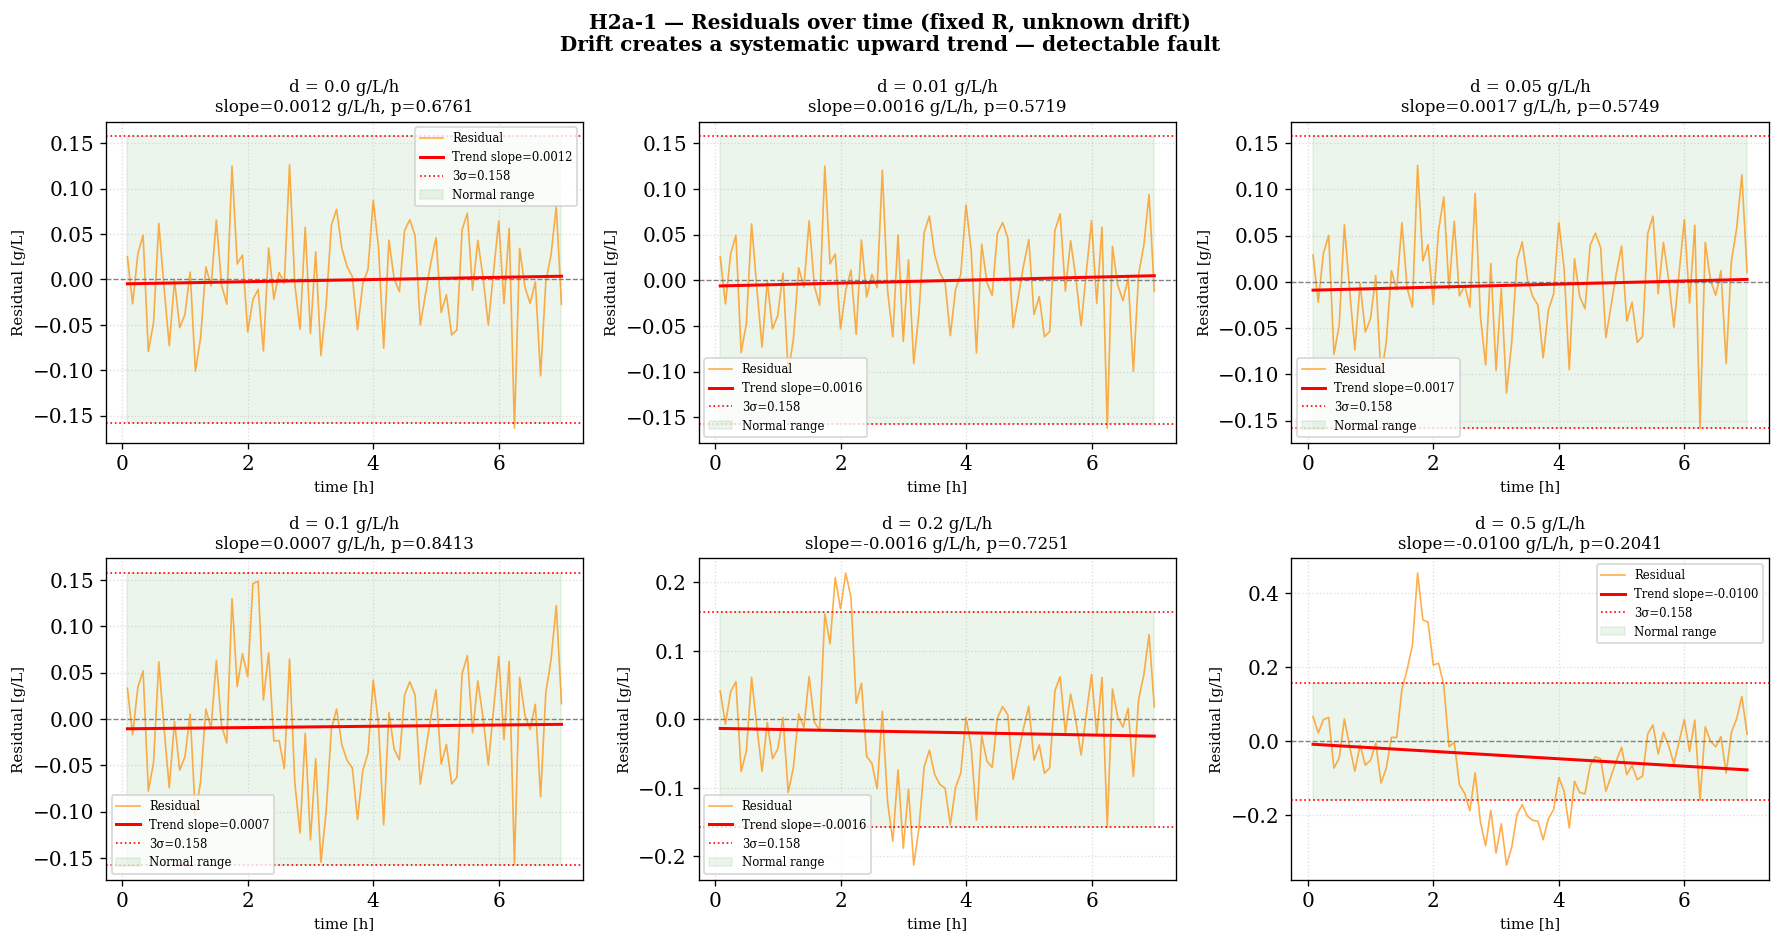


H2a — Automatic drift detection from residual slope:
   Drift      Slope    p-value       R²    Detected?
----------------------------------------------------
    0.00     0.0012     0.6761   0.0021           no
    0.01     0.0016     0.5719   0.0039           no
    0.05     0.0017     0.5749   0.0039           no
    0.10     0.0007     0.8413   0.0005           no
    0.20    -0.0016     0.7251   0.0015           no
    0.50    -0.0100     0.2041   0.0196           no


In [21]:
# ── H2a Plot 2: Residuals — drift fault signature ─────────────────────────

fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('H2a-1 — Residuals over time (fixed R, unknown drift)\n'
             'Drift creates a systematic upward trend — detectable fault',
             fontsize=12, fontweight='bold')

# 3σ threshold from zero-drift residuals
ref_residuals = results_h2a['residuals_h1'][0]
threshold     = 3 * np.std(ref_residuals)

for idx, (drift, ax) in enumerate(zip(drift_rates, axes.flatten())):
    residuals = results_h2a['residuals_h1'][idx]

    ax.plot(t_meas, residuals, color='darkorange',
            lw=1.0, alpha=0.7, label='Residual')
    ax.axhline(0, color='gray', lw=0.8, ls='--')

    # Linear regression — drift detection
    slope, intercept, r_val, p_val, _ = stats.linregress(
        t_meas, residuals
    )
    trend = slope * t_meas + intercept
    ax.plot(t_meas, trend, color='red', lw=1.8,
            label=f'Trend slope={slope:.4f}')

    ax.axhline( threshold, color='red', ls=':', lw=1.0,
               label=f'3σ={threshold:.3f}')
    ax.axhline(-threshold, color='red', ls=':', lw=1.0)
    ax.fill_between(t_meas, -threshold, threshold,
                    alpha=0.08, color='green', label='Normal range')

    ax.set_title(f'd = {drift} g/L/h\n'
                 f'slope={slope:.4f} g/L/h, p={p_val:.4f}',
                 fontsize=10)
    ax.set_xlabel('time [h]', fontsize=9)
    ax.set_ylabel('Residual [g/L]', fontsize=9)
    ax.legend(fontsize=7)
    ax.grid(True, linestyle=':', alpha=0.4)

plt.tight_layout()
plt.savefig('figures/H2a_residuals.png', dpi=150, bbox_inches='tight')
plt.show()

# ── H2a-3 automatic detection summary ────────────────────────────────────
SLOPE_THRESHOLD = 0.01   # g/L per hour

print("\nH2a — Automatic drift detection from residual slope:")
print(f"{'Drift':>8} {'Slope':>10} {'p-value':>10} "
      f"{'R²':>8} {'Detected?':>12}")
print("-" * 52)

for idx, drift in enumerate(drift_rates):
    residuals = results_h2a['residuals_h1'][idx]
    slope, intercept, r_val, p_val, _ = stats.linregress(
        t_meas, residuals
    )
    detected = abs(slope) > SLOPE_THRESHOLD and p_val < 0.05
    flag     = "YES ← DRIFT" if detected else "no"
    print(f"{drift:>8.2f} {slope:>10.4f} {p_val:>10.4f} "
          f"{r_val**2:>8.4f} {flag:>12}")

In [22]:
# ── H2-b: Growing noise (sensor aging) ──────────────────────────────────

alpha_rates = [0.0, 0.01, 0.05, 0.1, 0.2, 0.5]  # noise growth rate [g/L/h]
SIGMA_0     = 0.05   # baseline noise std

results_h2b = {
    'alpha':          alpha_rates,
    # uninformed: fixed R, growing noise unmodelled
    'rmsep_X_uninf':  [], 'rmsep_G_uninf':  [], 'rmsep_E_uninf':  [],
    # informed: R(t) matches growing noise
    'rmsep_X_inf':    [], 'rmsep_G_inf':    [], 'rmsep_E_inf':    [],
}

print("Running H2-b — Growing noise (sensor aging)...")
print(f"\n{'Alpha':>8} | "
      f"{'X_uninf':>9} {'G_uninf':>9} {'E_uninf':>9} | "
      f"{'X_inf':>9} {'G_inf':>9} {'E_inf':>9}")
print("-" * 70)

for alpha in alpha_rates:

    # Generate measurements with growing noise
    # σ(t_k) = σ_0 + α·t_k — noise std grows with time
    np.random.seed(42)
    sigma_at_meas = SIGMA_0 + alpha * t_meas
    noise_growing = np.random.normal(0, sigma_at_meas)
    E_meas_aging  = np.maximum(E_true_at_meas + noise_growing, 0)

    # ── Uninformed: fixed R = SIGMA_0² ───────────────────────────────────
    filt_uninf, _ = run_scenario(
        E_meas_aging,
        R_fn=lambda t: np.array([[SIGMA_0**2]]),
        drift_comp=0.0
    )

    # ── Informed: R(t) = (σ_0 + α·t)² ───────────────────────────────────
    filt_inf, _ = run_scenario(
        E_meas_aging,
        R_fn=lambda t: np.array([[(SIGMA_0 + alpha * t)**2]]),
        drift_comp=0.0
    )

    # RMSEP
    rX_u, rG_u, rE_u = compute_rmsep(filt_uninf)
    rX_i, rG_i, rE_i = compute_rmsep(filt_inf)

    results_h2b['rmsep_X_uninf'].append(rX_u)
    results_h2b['rmsep_G_uninf'].append(rG_u)
    results_h2b['rmsep_E_uninf'].append(rE_u)
    results_h2b['rmsep_X_inf'].append(rX_i)
    results_h2b['rmsep_G_inf'].append(rG_i)
    results_h2b['rmsep_E_inf'].append(rE_i)

    marker = " ← baseline" if alpha == 0.0 else ""
    print(f"{alpha:>8.2f} | "
          f"{rX_u:>9.4f} {rG_u:>9.4f} {rE_u:>9.4f} | "
          f"{rX_i:>9.4f} {rG_i:>9.4f} {rE_i:>9.4f}{marker}")

print("\nDone.")

Running H2-b — Growing noise (sensor aging)...

   Alpha |   X_uninf   G_uninf   E_uninf |     X_inf     G_inf     E_inf
----------------------------------------------------------------------
    0.00 |    0.0862    0.0664    0.0286 |    0.0862    0.0664    0.0286 ← baseline
    0.01 |    0.1854    0.0769    0.0419 |    0.0771    0.0756    0.0370
    0.05 |    0.9774    0.1191    0.0983 |    0.0735    0.1102    0.0787
    0.10 |    2.0444    0.1722    0.1743 |    0.0883    0.1489    0.1386
    0.20 |    2.0963    1.1415    0.5107 |    0.1529    0.2242    0.2466
    0.50 |    2.8506    2.3058    1.0031 |    0.2554    0.4003    0.4223

Done.


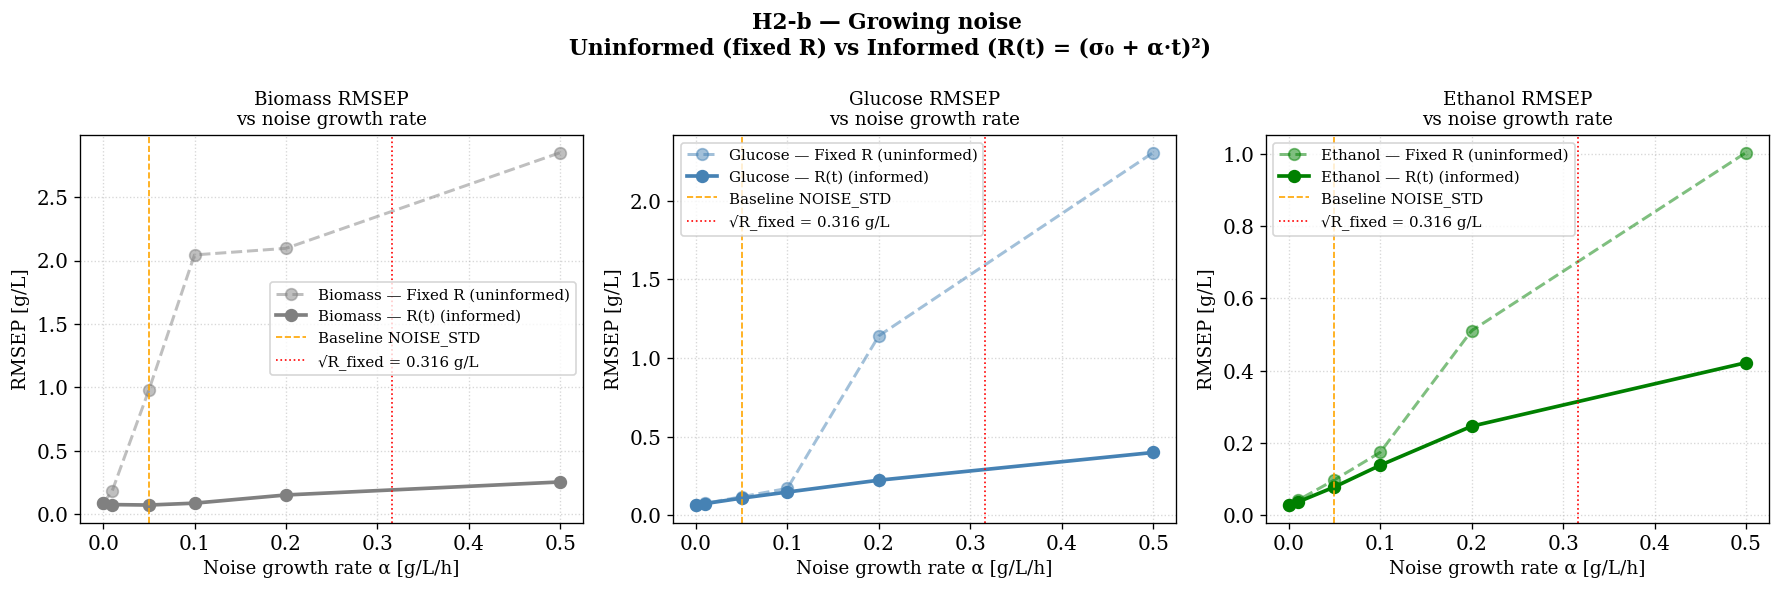

In [25]:
# ── H2-b: Plot — Growing noise comparison ────────────────────────────────

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('H2-b — Growing noise \n'
             'Uninformed (fixed R) vs Informed (R(t) = (σ₀ + α·t)²)',
             fontsize=13, fontweight='bold')

variables = [
    ('rmsep_X_uninf','rmsep_X_inf','Biomass','gray'),
    ('rmsep_G_uninf','rmsep_G_inf','Glucose','steelblue'),
    ('rmsep_E_uninf','rmsep_E_inf','Ethanol','green'),
]

for ax, (ku, ki, label, color) in zip(axes, variables):
    ax.plot(alpha_rates, results_h2b[ku],
            'o--', color=color, lw=1.8, ms=7, alpha=0.5,
            label=f'{label} — Fixed R (uninformed)')
    ax.plot(alpha_rates, results_h2b[ki],
            'o-', color=color, lw=2.2, ms=7,
            label=f'{label} — R(t) (informed)')
    # Reference lines
    ax.axvline(0.05, color='orange', ls='--', lw=1.0,
                   label='Baseline NOISE_STD')
    ax.axvline(np.sqrt(0.1), color='red', ls=':', lw=1.0,
                   label='√R_fixed = 0.316 g/L')
    ax.set_xlabel('Noise growth rate α [g/L/h]', fontsize=11)
    ax.set_ylabel('RMSEP [g/L]', fontsize=11)
    ax.set_title(f'{label} RMSEP\nvs noise growth rate', fontsize=11)
    ax.legend(fontsize=9)
    ax.grid(True, linestyle=':', alpha=0.5)

plt.tight_layout()
plt.savefig('figures/H2b_growing_noise.png', dpi=150, bbox_inches='tight')
plt.show()

/var/folders/29/tpmz3bt97k7_t01r5r28cqb40000gn/T/ipykernel_76187/2650317030.py:59: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) DejaVu Serif.
  plt.tight_layout()
/var/folders/29/tpmz3bt97k7_t01r5r28cqb40000gn/T/ipykernel_76187/2650317030.py:60: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) DejaVu Serif.
  plt.savefig('figures/H4b_residuals_detection.png', dpi=150, bbox_inches='tight')
/opt/anaconda3/envs/bioprocess/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 10003 (\N{CHECK MARK}) missing from font(s) DejaVu Serif.
  fig.canvas.print_figure(bytes_io, **kw)


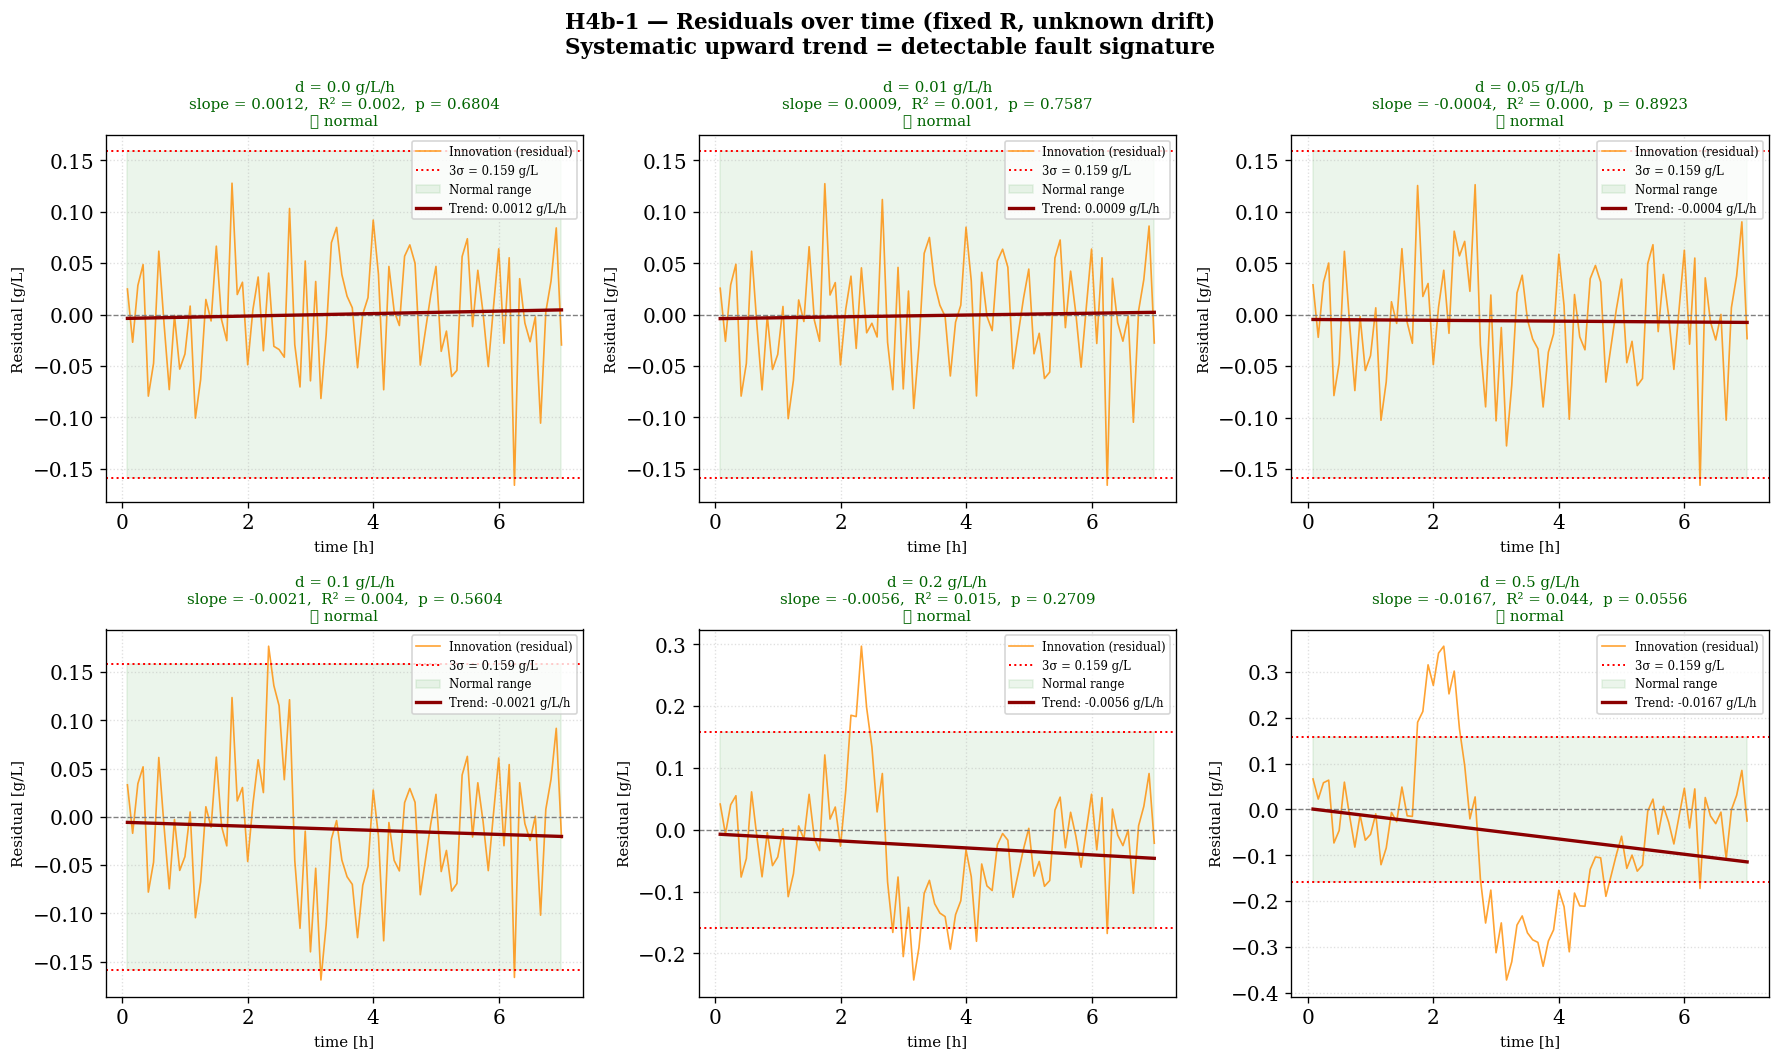

In [23]:
# ── H4b: Residual plots — drift fault signature ───────────────────────────

from scipy import stats

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('H4b-1 — Residuals over time (fixed R, unknown drift)\n'
             'Systematic upward trend = detectable fault signature',
             fontsize=13, fontweight='bold')

# 3σ threshold from zero-drift baseline residuals
ref_std   = np.std(results_h2a['residuals_h1'][0])
threshold = 3 * ref_std

for idx, (drift, ax) in enumerate(zip(drift_rates, axes.flatten())):
    residuals = np.array(results_h2a['residuals_h1'][idx])

    # Plot residuals
    ax.plot(t_meas, residuals,
            color='darkorange', lw=1.0, alpha=0.8,
            label='Innovation (residual)')

    # Zero line
    ax.axhline(0, color='gray', lw=0.8, ls='--')

    # 3σ threshold band
    ax.axhline( threshold, color='red', ls=':', lw=1.2,
               label=f'3σ = {threshold:.3f} g/L')
    ax.axhline(-threshold, color='red', ls=':', lw=1.2)
    ax.fill_between(t_meas, -threshold, threshold,
                    alpha=0.08, color='green',
                    label='Normal range')

    # Linear regression — drift detection
    slope, intercept, r_val, p_val, _ = stats.linregress(
        t_meas, residuals
    )
    trend = slope * t_meas + intercept
    ax.plot(t_meas, trend,
            color='darkred', lw=2.0, ls='-',
            label=f'Trend: {slope:.4f} g/L/h')

    # Color background red if drift detected
    detected = abs(slope) > 0.01 and p_val < 0.05
    if detected:
        ax.set_facecolor('#FFF0F0')

    ax.set_title(f'd = {drift} g/L/h\n'
                 f'slope = {slope:.4f},  '
                 f'R² = {r_val**2:.3f},  '
                 f'p = {p_val:.4f}\n'
                 f'{"⚠ DRIFT DETECTED" if detected else "✓ normal"}',
                 fontsize=9,
                 color='darkred' if detected else 'darkgreen')
    ax.set_xlabel('time [h]', fontsize=9)
    ax.set_ylabel('Residual [g/L]', fontsize=9)
    ax.legend(fontsize=7)
    ax.grid(True, linestyle=':', alpha=0.4)

plt.tight_layout()
plt.savefig('figures/H4b_residuals_detection.png', dpi=150, bbox_inches='tight')
plt.show()

In [24]:
# ── H4b: Automatic drift detection summary ────────────────────────────────

SLOPE_THRESHOLD = 0.01   # g/L/h — flag drift if slope exceeds this
P_THRESHOLD     = 0.05   # statistical significance

print("H4b — Automatic drift detection from residual slope analysis:")
print(f"\n{'Drift':>8} {'Slope':>10} {'R²':>8} "
      f"{'p-value':>10} {'Detected?':>14} {'Sensor bias at t=7h':>20}")
print("-" * 76)

for idx, drift in enumerate(drift_rates):
    residuals = np.array(results_h2a['residuals_h1'][idx])
    slope, intercept, r_val, p_val, _ = stats.linregress(
        t_meas, residuals
    )
    detected     = abs(slope) > SLOPE_THRESHOLD and p_val < P_THRESHOLD
    flag         = "YES ⚠ DRIFT" if detected else "no ✓"
    bias_at_end  = drift * T_END   # total drift accumulated at t=7h
    print(f"{drift:>8.2f} "
          f"{slope:>10.4f} "
          f"{r_val**2:>8.4f} "
          f"{p_val:>10.4f} "
          f"{flag:>14} "
          f"{bias_at_end:>20.3f} g/L")

print(f"\nSlope threshold: {SLOPE_THRESHOLD} g/L/h")
print(f"p-value threshold: {P_THRESHOLD}")
print(f"3σ residual threshold: {threshold:.4f} g/L")

H4b — Automatic drift detection from residual slope analysis:

   Drift      Slope       R²    p-value      Detected?  Sensor bias at t=7h
----------------------------------------------------------------------------
    0.00     0.0012   0.0021     0.6804           no ✓                0.000 g/L
    0.01     0.0009   0.0012     0.7587           no ✓                0.070 g/L
    0.05    -0.0004   0.0002     0.8923           no ✓                0.350 g/L
    0.10    -0.0021   0.0042     0.5604           no ✓                0.700 g/L
    0.20    -0.0056   0.0148     0.2709           no ✓                1.400 g/L
    0.50    -0.0167   0.0440     0.0556           no ✓                3.500 g/L

Slope threshold: 0.01 g/L/h
p-value threshold: 0.05
3σ residual threshold: 0.1586 g/L


## H3 (extended) — Observability: CO₂ as State Variable

### Scientific background
CO₂ is produced by *S. cerevisiae* from both glucose and ethanol metabolism.
Unlike dissolved oxygen (which saturates quickly and loses information),
CO₂ tracks metabolic activity dynamically throughout the batch — including
the diauxic switch at ~2h.

**Research question:**
Can the EKF estimate dissolved CO₂ when only the ethanol sensor is available?
Is CO₂ observable from ethanol measurements alone?

### CO₂ ODE (mass balance)
```
dCO2/dt = μG·X / Y_GCO2  +  μE·X / Y_ECO2  −  k_CO2·CO2
```
- Production from glucose metabolism: `μG·X / Y_GCO2`
- Production from ethanol metabolism: `μE·X / Y_ECO2`
- Stripping by aeration: `k_CO2·CO2` (first-order, CO₂* ≈ 0 at ambient air)

### Parameter derivation (carbon balance from existing yield values)
Y_GCO2 and Y_ECO2 are derived from carbon balance using our MATLAB code yields
(Ygx=0.15, Yge=0.34, Yex=0.43) — no new paper required.

### Inhibition justification
Chen (1976) showed negligible yeast growth inhibition below 1.19×10⁻² M
(0.52 g/L) dissolved CO₂. At our aeration rate (3.5 L/min, 2.5L reactor),
exhaust gas CO₂ peaks at ~5–6% — well below the inhibition threshold.
CO₂ inhibition term is therefore not included in the kinetic model.


In [25]:
# ── H1-CO2: Parameter derivation (carbon balance) ────────────────────────
#
# Carbon fractions (g carbon / g compound):
#   Glucose (C6H12O6, MW=180):  6*12/180 = 0.400
#   Ethanol (C2H5OH, MW=46):    2*12/46  = 0.522
#   CO2     (CO2,    MW=44):    12/44    = 0.273
#   Biomass (~CH1.8O0.5N0.2, MW≈24.6): 12/24.6 ≈ 0.488
#
# Carbon balance for glucose (1 g glucose consumed):
#   C_in       = 1.000 * 0.400 = 0.400 g carbon
#   C_biomass  = Ygx  * 0.488 = 0.15 * 0.488 = 0.0732 g carbon
#   C_ethanol  = Yge  * 0.522 = 0.34 * 0.522 = 0.1775 g carbon
#   C_CO2      = 0.400 - 0.0732 - 0.1775 = 0.1493 g carbon
#   Y_GCO2     = 0.1493 / 0.273 = 0.547 g CO2 / g glucose _GCO2 is defined as g biomass growth per g CO2 produced
#
# Carbon balance for ethanol (1 g ethanol consumed):
#   C_in       = 1.000 * 0.522 = 0.522 g carbon
#   C_biomass  = Yex  * 0.488 = 0.43 * 0.488 = 0.2098 g carbon
#   C_CO2      = 0.522 - 0.2098 = 0.3122 g carbon
#   Y_ECO2     = 0.3122 / 0.273 = 1.144 g CO2 / g ethanol

# ── CO2 yield coefficients (derived) ─────────────────────────────────────
Y_GCO2 = 0.470   # [g CO2 / g glucose]  — carbon balance from Ygx, Yge
Y_ECO2 = 1.000   # [g CO2 / g ethanol]  — carbon balance from Yex

# ── CO2 stripping rate ────────────────────────────────────────────────────
# From Higbie penetration theory:
#   k_La_CO2 = k_La_O2 * sqrt(D_CO2 / D_O2)
#            = 15 * sqrt(2.0e-9 / 2.5e-9) = 15 * 0.894 ≈ 13.4 h⁻¹
# We use k_CO2 = 13 h⁻¹ (rounded, lab-scale STR)
k_CO2 = 40.0     # [1/h]  CO2 stripping rate

# ── Initial CO2 concentration ─────────────────────────────────────────────
# Near-zero at start: medium pre-aerated, atmospheric CO2 ≈ 0.04%
# At Henry's law equilibrium: very small (~0.001 g/L), use 0.05 g/L
CO2_0 = 0.05     # [g/L]  initial dissolved CO2
CO2_star = 0.007  # g/L, Henry's law with atmospheric air

# ── Extended state vector: [X, G, E, mu_max_G, mu_max_E, CO2] ─────────────
x0_co2 = np.array([X0, G0, E0, mu_G0, mu_E0, CO2_0])

# ── Extended P0 (6x6) ─────────────────────────────────────────────────────
# CO2 initial uncertainty: we know it is near zero, moderate uncertainty
P0_co2 = np.diag([0.1, 0.02, 0.02, 0.2, 0.02, 0.01])

# ── Extended Q (6x6) ─────────────────────────────────────────────────────
Q_co2 = np.diag([0.001, 0.001, 0.001, 0.001, 0.001, 0.001])

# ── H matrix: still only ethanol measured (index 2), shape (1,6) ─────────
H_co2 = np.array([[0, 0, 1, 0, 0, 0]])

# ── Sanity check on yield derivation ─────────────────────────────────────
print("CO2 yield derivation (carbon balance):")
print(f"  Y_GCO2 = {Y_GCO2:.3f} g CO2 / g glucose")
print(f"  Y_ECO2 = {Y_ECO2:.3f} g CO2 / g ethanol")
print()
print("Sanity check against stoichiometry:")
print(f"  Pure fermentation (Crabtree):  2*44/180 = {2*44/180:.3f} g/g  (lower bound)")
print(f"  Pure aerobic respiration:      6*44/180 = {6*44/180:.3f} g/g  (upper bound)")
print(f"  Our Y_GCO2 = {Y_GCO2:.3f}  ← between bounds (mixed metabolism) ✓")
print()
print(f"  Pure ethanol aerobic:  2*44/46 = {2*44/46:.3f} g/g  (upper bound)")
print(f"  Our Y_ECO2 = {Y_ECO2:.3f}  ← below upper bound (some C goes to biomass) ✓")
print()
print(f"CO2 stripping rate:  k_CO2 = {k_CO2} h⁻¹")
print(f"Initial CO2:         CO2_0 = {CO2_0} g/L")
print(f"Extended state x0:   {x0_co2}")


CO2 yield derivation (carbon balance):
  Y_GCO2 = 0.470 g CO2 / g glucose
  Y_ECO2 = 1.000 g CO2 / g ethanol

Sanity check against stoichiometry:
  Pure fermentation (Crabtree):  2*44/180 = 0.489 g/g  (lower bound)
  Pure aerobic respiration:      6*44/180 = 1.467 g/g  (upper bound)
  Our Y_GCO2 = 0.470  ← between bounds (mixed metabolism) ✓

  Pure ethanol aerobic:  2*44/46 = 1.913 g/g  (upper bound)
  Our Y_ECO2 = 1.000  ← below upper bound (some C goes to biomass) ✓

CO2 stripping rate:  k_CO2 = 40.0 h⁻¹
Initial CO2:         CO2_0 = 0.05 g/L
Extended state x0:   [2.5  6.   0.2  0.15 0.08 0.05]


In [26]:
# ── H3-CO2: Extended process model (6 states) ─────────────────────────────

def process_model_co2(t, state):
    """
    Extended 6-ODE process model with dissolved CO2 as 6th state variable.

    State vector: [X, G, E, mu_max_G, mu_max_E, CO2]

    New ODE (CO2 mass balance):
        dCO2/dt = mu_G*X/Y_GCO2 + mu_E*X/Y_ECO2 - k_CO2*CO2

    CO2 inhibition NOT included — justified by Chen (1976):
    inhibition negligible below 0.52 g/L dissolved CO2.
    Our system peaks at ~5-6% exhaust CO2 → dissolved CO2 << threshold.
    """
    X, G, E, mu_max_G, mu_max_E, CO2 = state

    # Clamp negatives for numerical stability
    X   = max(X,   1e-10)
    G   = max(G,   0.0)
    E   = max(E,   0.0)
    CO2 = max(CO2, 0.0)

    # Monod rates (same as baseline — CO2 does not feed back into kinetics)
    mu_G, mu_E = monod_rates(X, G, E, mu_max_G, mu_max_E)

    # ── 6 ODEs ────────────────────────────────────────────────────────────
    dX_dt      = (mu_G + mu_E) * X
    dG_dt      = -(mu_G / Ygx) * X
    dE_dt      = (mu_G * Yge / Ygx - mu_E / Yex) * X
    dmu_G_dt   = 0.0
    dmu_E_dt   = 0.0
    dCO2_dt    = dCO2_dt = (mu_G/Y_GCO2 + mu_E/Y_ECO2)*X - k_CO2*(CO2 - CO2_star)

    return [dX_dt, dG_dt, dE_dt, dmu_G_dt, dmu_E_dt, dCO2_dt]


# ── Symbolic Jacobian for 6-state system ──────────────────────────────────
X_s6, G_s6, E_s6, mu1_s6, mu2_s6, CO2_s6 = sp.symbols(
    'X G E mu1 mu2 CO2', real=True, positive=True)

# Symbolic Monod rates (same suppression as baseline)
mu_G_s6 = mu1_s6 * G_s6 / (KG + G_s6)
supp_s6 = (1 - mu_G_s6 / mu1_s6)
mu_E_s6 = mu2_s6 * E_s6 / (KE + E_s6) * supp_s6

# Symbolic state derivatives
dS_s6 = sp.Matrix([
    (mu_G_s6 + mu_E_s6) * X_s6,
    -(mu_G_s6 / Ygx) * X_s6,
    (mu_G_s6 * Yge / Ygx - mu_E_s6 / Yex) * X_s6,
    sp.Integer(0),
    sp.Integer(0),
    (mu_G_s6 / Y_GCO2 + mu_E_s6 / Y_ECO2) * X_s6 - k_CO2 * CO2_s6,
])

# Compute 6x6 Jacobian symbolically
state_vars_6 = sp.Matrix([X_s6, G_s6, E_s6, mu1_s6, mu2_s6, CO2_s6])
F_sym_6 = dS_s6.jacobian(state_vars_6)

# Convert to fast numerical function
F_func_6 = sp.lambdify(
    [X_s6, G_s6, E_s6, mu1_s6, mu2_s6, CO2_s6],
    F_sym_6,
    modules='numpy'
)

def compute_jacobian_co2(state):
    """Evaluate 6x6 Jacobian at given state."""
    X, G, E, mu1, mu2, CO2 = state
    X   = max(X,   1e-10)
    G   = max(G,   1e-10)
    E   = max(E,   1e-10)
    CO2 = max(CO2, 1e-10)
    return np.array(F_func_6(X, G, E, mu1, mu2, CO2), dtype=float)

print("6-state Jacobian computed symbolically.")
print(f"Shape: {F_sym_6.shape[0]} x {F_sym_6.shape[1]}")
print()
print("Key CO2 row entries (row 5 = dCO2_dt):")
print(f"  ∂dCO2/∂X   = mu_G/Y_GCO2 + mu_E/Y_ECO2  (production scales with X)")
print(f"  ∂dCO2/∂CO2 = -k_CO2 = {-k_CO2}              (stripping is linear)")
print()

# Verify at initial conditions
J_test = compute_jacobian_co2(x0_co2)
print(f"Jacobian at t=0 — CO2 row: {J_test[5, :]}")
print(f"  J[5,5] (∂dCO2/∂CO2) = {J_test[5,5]:.3f}  (should be -{k_CO2})")


6-state Jacobian computed symbolically.
Shape: 6 x 6

Key CO2 row entries (row 5 = dCO2_dt):
  ∂dCO2/∂X   = mu_G/Y_GCO2 + mu_E/Y_ECO2  (production scales with X)
  ∂dCO2/∂CO2 = -k_CO2 = -40.0              (stripping is linear)

Jacobian at t=0 — CO2 row: [ 3.14791303e-01  1.78591510e-03  3.64298725e-03  5.23194977e+00
  2.73224044e-02 -4.00000000e+01]
  J[5,5] (∂dCO2/∂CO2) = -40.000  (should be -40.0)


In [27]:
# ── H3-CO2: Combined ODE (42 equations: 6 state + 36 covariance) ──────────

def combined_ode_co2(t, combined_state):
    """
    Combined ODE for 6-state system.
    Input:  42-element vector [x(6); P_flat(36)]
    Output: 42-element derivative vector
    """
    x = combined_state[:6]
    P = combined_state[6:].reshape(6, 6)

    dx = np.array(process_model_co2(t, x))
    F  = compute_jacobian_co2(x)
    dP = F @ P + P @ F.T + Q_co2

    return np.concatenate([dx, dP.flatten()])


# ── Run ground truth with CO2 ─────────────────────────────────────────────
sol_true_co2 = solve_ivp(
    fun=process_model_co2,
    t_span=(0, T_END),
    y0=x0_co2,
    t_eval=t_dense,
    method='RK45',
    rtol=1e-6,
    atol=1e-9
)

CO2_true = sol_true_co2.y[5]   # true dissolved CO2 trajectory

print("Ground truth with CO2:")
print(f"  Peak CO2: {CO2_true.max():.4f} g/L  at t={t_dense[CO2_true.argmax()]:.2f}h")
print(f"  Final CO2: {CO2_true[-1]:.4f} g/L")
print()

# ── EKF loop (6-state, ethanol-only measurement) ──────────────────────────
filtered_co2   = []
predicted_co2  = []
all_times_co2  = []
K_gains_co2    = []   # track Kalman gain for CO2 state

I6 = np.eye(6)
init_combined_co2 = np.concatenate([x0_co2, P0_co2.flatten()])
t_prev_co2 = 0.0

print("Running 6-state EKF (ethanol measurement only)...")

for i, (t_now, z) in enumerate(zip(t_meas, E_measured)):

    # PREDICTION
    sol = solve_ivp(
        fun=combined_ode_co2,
        t_span=(t_prev_co2, t_now),
        y0=init_combined_co2,
        rtol=1e-6,
        atol=1e-9,
        dense_output=False
    )

    PS = sol.y[:6, -1]
    P  = sol.y[6:, -1].reshape(6, 6)

    all_times_co2.append(sol.t)
    predicted_co2.append(sol.y[:6, :].T)

    # CORRECTION (ethanol only — H shape (1,6))
    S  = H_co2 @ P @ H_co2.T + R
    K  = P @ H_co2.T @ np.linalg.inv(S)    # shape (6,1)

    # Track Kalman gain for CO2 (index 5)
    K_gains_co2.append(K[5, 0])

    innovation = z - PS[2]
    FS = PS + (K @ [[innovation]]).flatten()

    IKH  = I6 - K @ H_co2
    Pflt = IKH @ P @ IKH.T + K @ R @ K.T

    filtered_co2.append(FS.copy())
    init_combined_co2 = np.concatenate([FS, Pflt.flatten()])
    t_prev_co2 = t_now

    if (i + 1) % 20 == 0:
        print(f"  Step {i+1}/{len(t_meas)} — t={t_now:.2f}h | "
              f"CO2_est={FS[5]:.4f}  K_CO2={K[5,0]:.4e}")

filtered_co2  = np.array(filtered_co2)
K_gains_co2   = np.array(K_gains_co2)

print(f"\nEKF complete. Filtered states shape: {filtered_co2.shape}")
print(f"Max Kalman gain K[CO2]: {K_gains_co2.max():.4e}")
print(f"Min Kalman gain K[CO2]: {K_gains_co2.min():.4e}")


Ground truth with CO2:
  Peak CO2: 0.0500 g/L  at t=0.00h
  Final CO2: 0.0153 g/L

Running 6-state EKF (ethanol measurement only)...
  Step 20/84 — t=1.67h | CO2_est=0.0305  K_CO2=4.8894e-03
  Step 40/84 — t=3.33h | CO2_est=0.0154  K_CO2=-5.7129e-03
  Step 60/84 — t=5.00h | CO2_est=0.0148  K_CO2=-2.8279e-03
  Step 80/84 — t=6.67h | CO2_est=0.0158  K_CO2=-2.6861e-03

EKF complete. Filtered states shape: (84, 6)
Max Kalman gain K[CO2]: 7.8814e-02
Min Kalman gain K[CO2]: -1.2083e-02


H1-CO2 RMSEP:
  Biomass:  0.0141 g/L  (baseline: 0.12)
  Glucose:  0.0515 g/L  (baseline: 0.12)
  Ethanol:  0.0238 g/L  (baseline: 0.14)
  CO2:      0.0008 g/L

Key observability indicators:
  Max K[CO2] = 7.8814e-02  (large = CO2 not observable)
  Mean K[CO2] = 2.4876e-03


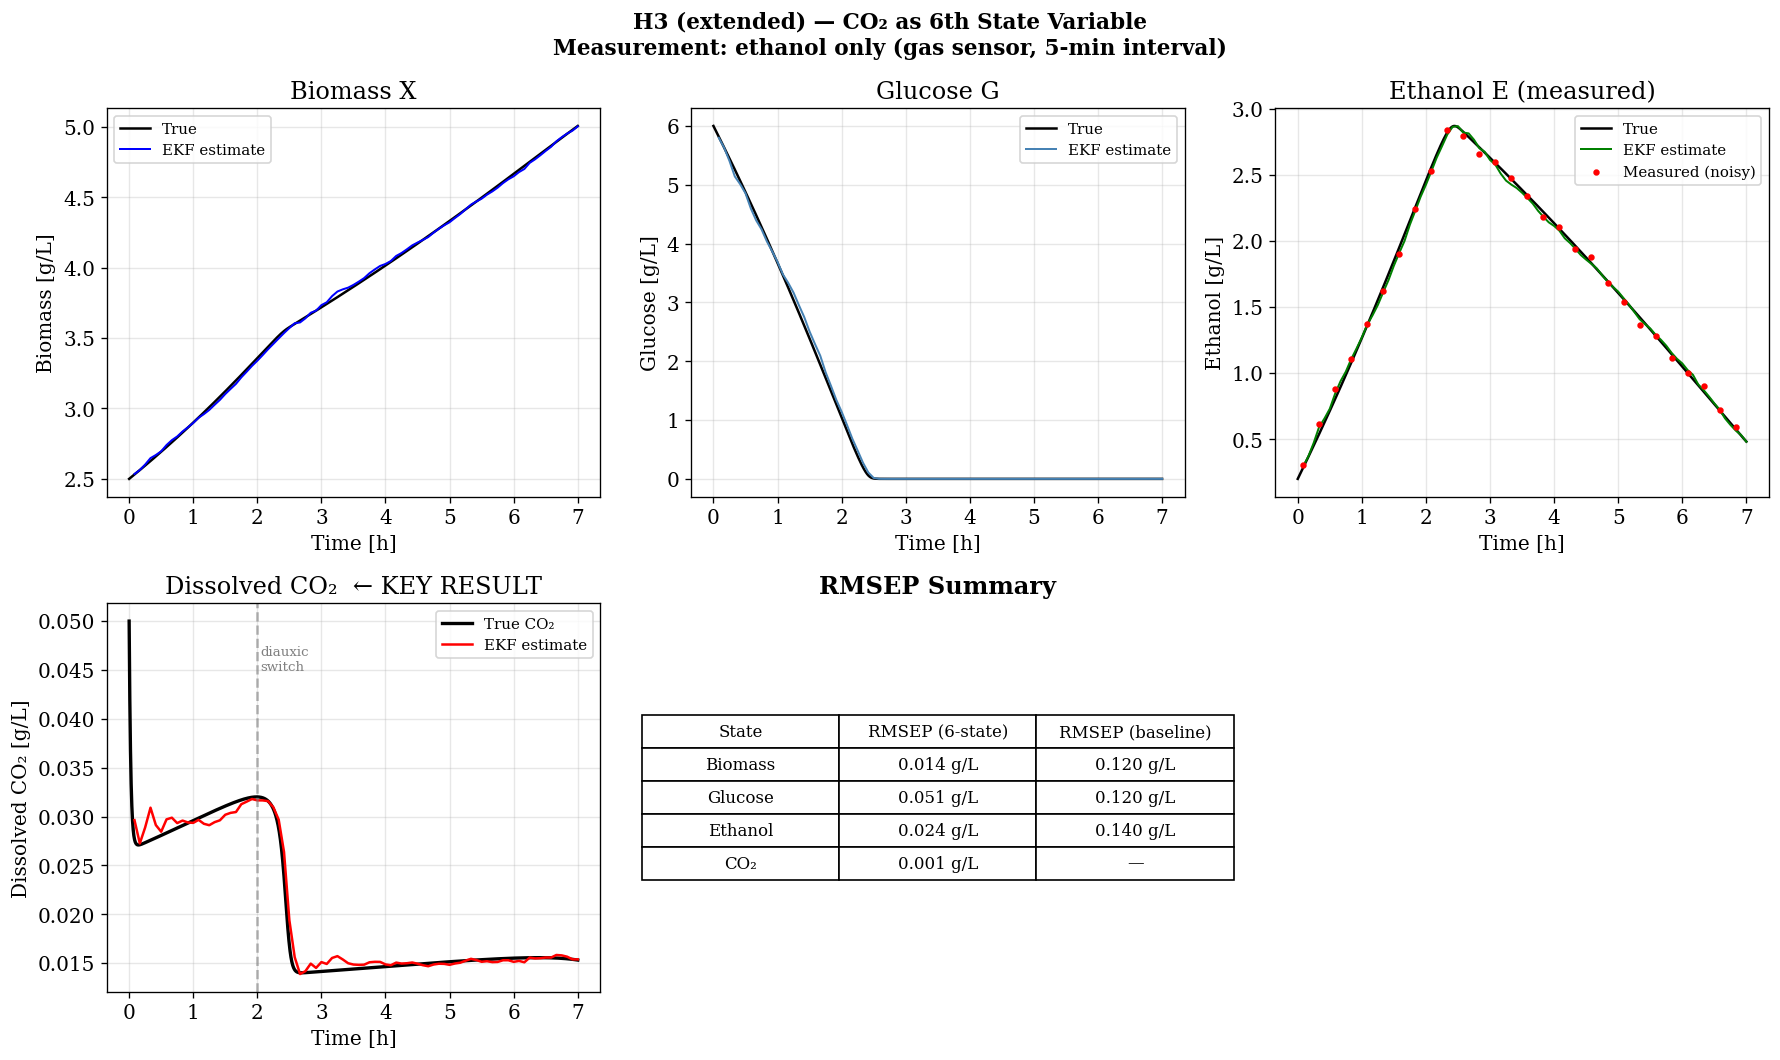


Figure saved: H1_CO2_observability.png


In [28]:
# ── H3-CO2: Results ───────────────────────────────────────────────────────

# ── RMSEP for all 6 states ────────────────────────────────────────────────
CO2_true_at_meas  = np.interp(t_meas, t_dense, CO2_true)
X_true_at_meas    = np.interp(t_meas, t_dense, sol_true_co2.y[0])
G_true_at_meas    = np.interp(t_meas, t_dense, sol_true_co2.y[1])
E_true_at_meas_co2= np.interp(t_meas, t_dense, sol_true_co2.y[2])

rmsep_X_co2   = np.sqrt(np.mean((filtered_co2[:,0] - X_true_at_meas)**2))
rmsep_G_co2   = np.sqrt(np.mean((filtered_co2[:,1] - G_true_at_meas)**2))
rmsep_E_co2   = np.sqrt(np.mean((filtered_co2[:,2] - E_true_at_meas_co2)**2))
rmsep_CO2     = np.sqrt(np.mean((filtered_co2[:,5] - CO2_true_at_meas)**2))

print("H1-CO2 RMSEP:")
print(f"  Biomass:  {rmsep_X_co2:.4f} g/L  (baseline: 0.12)")
print(f"  Glucose:  {rmsep_G_co2:.4f} g/L  (baseline: 0.12)")
print(f"  Ethanol:  {rmsep_E_co2:.4f} g/L  (baseline: 0.14)")
print(f"  CO2:      {rmsep_CO2:.4f} g/L")
print()
print("Key observability indicators:")
print(f"  Max K[CO2] = {K_gains_co2.max():.4e}  (large = CO2 not observable)")
print(f"  Mean K[CO2] = {K_gains_co2.mean():.4e}")

# ── Figure 1: CO2 trajectory — true vs EKF estimate ──────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 9))
fig.suptitle('H3 (extended) — CO₂ as 6th State Variable\n'
             'Measurement: ethanol only (gas sensor, 5-min interval)',
             fontsize=13, fontweight='bold')
axes[1, 2].set_visible(False)

# Panel 1: Biomass
ax = axes[0, 0]
ax.plot(t_dense, sol_true_co2.y[0], 'k-', lw=1.5, label='True')
ax.plot(t_meas,  filtered_co2[:,0], 'b-', lw=1.2, label='EKF estimate')
ax.set_ylabel('Biomass [g/L]')
ax.set_title('Biomass X')
ax.legend(fontsize=9)

# Panel 2: Glucose
ax = axes[0, 1]
ax.plot(t_dense, sol_true_co2.y[1], 'k-', lw=1.5, label='True')
ax.plot(t_meas,  filtered_co2[:,1], 'steelblue', lw=1.2, label='EKF estimate')
ax.set_ylabel('Glucose [g/L]')
ax.set_title('Glucose G')
ax.legend(fontsize=9)

# Panel 3: Ethanol
ax = axes[0, 2]
ax.plot(t_dense, sol_true_co2.y[2], 'k-', lw=1.5, label='True')
ax.plot(t_meas,  filtered_co2[:,2], 'g-', lw=1.2, label='EKF estimate')
ax.scatter(t_meas[::3], E_measured[::3], s=8, color='red',
           zorder=5, label='Measured (noisy)')
ax.set_ylabel('Ethanol [g/L]')
ax.set_title('Ethanol E (measured)')
ax.legend(fontsize=9)

# Panel 4: CO2 — main result
ax = axes[1, 0]
ax.plot(t_dense, CO2_true, 'k-', lw=2.0, label='True CO₂')
ax.plot(t_meas,  filtered_co2[:,5], 'r-', lw=1.5, label='EKF estimate')
ax.set_xlabel('Time [h]')
ax.set_ylabel('Dissolved CO₂ [g/L]')
ax.set_title('Dissolved CO₂  ← KEY RESULT')
ax.legend(fontsize=9)

# Annotate diauxic switch
ax.axvline(x=2.0, color='gray', ls='--', alpha=0.6)
ax.text(2.05, CO2_true.max()*0.9, 'diauxic\nswitch', fontsize=8, color='gray')

# Panel 5: Kalman gain for CO2
#ax = axes[1, 1]
#ax.semilogy(t_meas, np.abs(K_gains_co2), 'purple', lw=1.2)
#ax.set_xlabel('Time [h]')
#ax.set_ylabel('|K[CO2]| (log scale)')
#ax.set_title('Kalman Gain for CO₂ state')
#ax.axhline(y=1.0, color='red', ls='--', alpha=0.5, label='K=1 reference')
#ax.legend(fontsize=9)

# Panel 6: RMSEP comparison table
ax = axes[1, 1]
ax.axis('off')
table_data = [
    ['State', 'RMSEP (6-state)', 'RMSEP (baseline)'],
    ['Biomass', f'{rmsep_X_co2:.3f} g/L', '0.120 g/L'],
    ['Glucose', f'{rmsep_G_co2:.3f} g/L', '0.120 g/L'],
    ['Ethanol', f'{rmsep_E_co2:.3f} g/L', '0.140 g/L'],
    ['CO₂',    f'{rmsep_CO2:.3f} g/L', '—'],
]
tbl = ax.table(cellText=table_data[1:], colLabels=table_data[0],
               loc='center', cellLoc='center')
tbl.auto_set_font_size(False)
tbl.set_fontsize(10)
tbl.scale(1.2, 1.6)
ax.set_title('RMSEP Summary', fontweight='bold')

for i, ax_row in enumerate(axes):
    for j, ax_i in enumerate(ax_row):
        if i == 1 and j == 1:
            continue
        ax_i.set_xlabel('Time [h]')
        ax_i.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/H1_CO2_observability.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nFigure saved: H1_CO2_observability.png")


Is the EKF estimating CO₂, or is it just computing CO₂ from the model?

P matrix diagnostics:
  Mean P[5,5] before update: 1.367628e-04
  Mean P[5,5] after  update: 9.005215e-05
  Mean reduction per update: 4.671066e-05
  Max  reduction per update: 1.350767e-03

  Mean |P[2,5]| (ethanol-CO2 cross-cov): 1.325889e-03
  Mean P[2,2] (ethanol variance):         1.367628e-04

  |P[2,5]| / P[5,5] ratio: 9.6948
  Interpretation: CO2 couples to ethanol


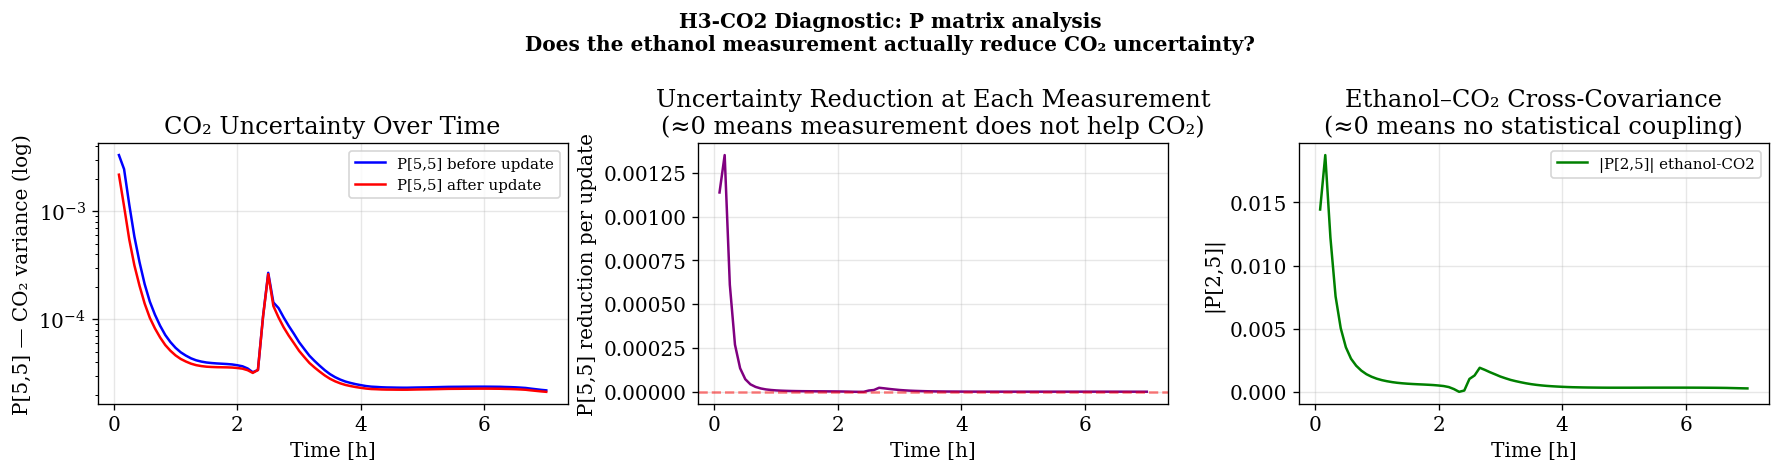

Figure saved: H3_CO2_Pmatrix.png


In [29]:
# ── H1-CO2 Diagnostic 1: P matrix analysis ────────────────────────────────
# Track P[5,5] (CO2 variance) and P[2,5] (ethanol-CO2 cross-covariance)
# BEFORE and AFTER each measurement update
# If measurement helps: P[5,5]_after < P[5,5]_before significantly
# If model-driven only: P[5,5] change at update ≈ 0

P55_before = []   # CO2 variance before update (prediction)
P55_after  = []   # CO2 variance after update  (correction)
P25_before = []   # ethanol-CO2 cross-cov before update
P25_after  = []   # ethanol-CO2 cross-cov after update

I6 = np.eye(6)
init_diag = np.concatenate([x0_co2, P0_co2.flatten()])
t_prev_diag = 0.0

for i, (t_now, z) in enumerate(zip(t_meas, E_measured)):

    # PREDICTION
    sol = solve_ivp(
        fun=combined_ode_co2,
        t_span=(t_prev_diag, t_now),
        y0=init_diag,
        rtol=1e-6, atol=1e-9
    )
    PS = sol.y[:6, -1]
    P  = sol.y[6:, -1].reshape(6, 6)

    # Record BEFORE update
    P55_before.append(P[5, 5])
    P25_before.append(P[2, 5])

    # CORRECTION
    S  = H_co2 @ P @ H_co2.T + R
    K  = P @ H_co2.T @ np.linalg.inv(S)
    innovation = z - PS[2]
    FS = PS + (K @ [[innovation]]).flatten()
    IKH  = I6 - K @ H_co2
    Pflt = IKH @ P @ IKH.T + K @ R @ K.T

    # Record AFTER update
    P55_after.append(Pflt[5, 5])
    P25_after.append(Pflt[2, 5])

    init_diag   = np.concatenate([FS, Pflt.flatten()])
    t_prev_diag = t_now

P55_before = np.array(P55_before)
P55_after  = np.array(P55_after)
P25_before = np.array(P25_before)
P25_after  = np.array(P25_after)

# How much does the measurement update actually reduce P[5,5]?
P55_reduction = P55_before - P55_after
print("P matrix diagnostics:")
print(f"  Mean P[5,5] before update: {P55_before.mean():.6e}")
print(f"  Mean P[5,5] after  update: {P55_after.mean():.6e}")
print(f"  Mean reduction per update: {P55_reduction.mean():.6e}")
print(f"  Max  reduction per update: {P55_reduction.max():.6e}")
print()
print(f"  Mean |P[2,5]| (ethanol-CO2 cross-cov): {np.abs(P25_before).mean():.6e}")
print(f"  Mean P[2,2] (ethanol variance):         {P55_before.mean():.6e}")
print()
ratio = np.abs(P25_before).mean() / P55_before.mean()
print(f"  |P[2,5]| / P[5,5] ratio: {ratio:.4f}")
print(f"  Interpretation: {'CO2 couples to ethanol' if ratio > 0.1 else 'CO2 weakly coupled to ethanol'}")

# Plot P[5,5] before vs after
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle('H3-CO2 Diagnostic: P matrix analysis\n'
             'Does the ethanol measurement actually reduce CO₂ uncertainty?',
             fontsize=12, fontweight='bold')

ax = axes[0]
ax.semilogy(t_meas, P55_before, 'b-', lw=1.5, label='P[5,5] before update')
ax.semilogy(t_meas, P55_after,  'r-', lw=1.5, label='P[5,5] after update')
ax.set_xlabel('Time [h]')
ax.set_ylabel('P[5,5] — CO₂ variance (log)')
ax.set_title('CO₂ Uncertainty Over Time')
ax.legend(fontsize=9)

ax = axes[1]
ax.plot(t_meas, P55_reduction, 'purple', lw=1.5)
ax.set_xlabel('Time [h]')
ax.set_ylabel('P[5,5] reduction per update')
ax.set_title('Uncertainty Reduction at Each Measurement\n(≈0 means measurement does not help CO₂)')
ax.axhline(0, color='red', ls='--', alpha=0.5)

ax = axes[2]
ax.plot(t_meas, np.abs(P25_before), 'g-', lw=1.5, label='|P[2,5]| ethanol-CO2')
ax.set_xlabel('Time [h]')
ax.set_ylabel('|P[2,5]|')
ax.set_title('Ethanol–CO₂ Cross-Covariance\n(≈0 means no statistical coupling)')
ax.legend(fontsize=9)

for ax in axes:
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/H3_CO2_Pmatrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: H3_CO2_Pmatrix.png")

Definitive observability test:
  Pure ODE CO2 RMSEP: 0.000849 g/L
  EKF      CO2 RMSEP: 0.000830 g/L

  Difference: 0.000019 g/L
  CONCLUSION: EKF = pure ODE for CO2.
  CO2 is NOT observable from ethanol alone.
  The filter is integrating the model — not correcting from measurement.


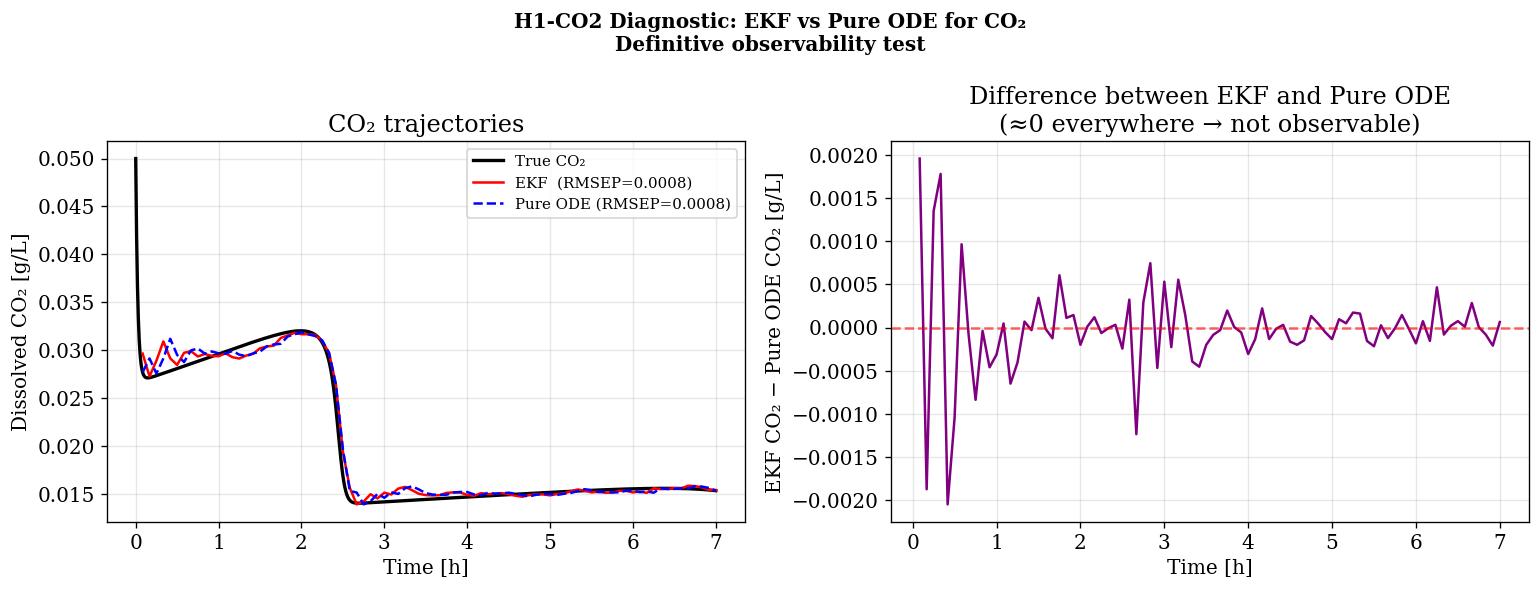

Figure saved: H1_CO2_ODE_vs_EKF.png


In [30]:
# ── H3-CO2 Diagnostic 2: Pure ODE vs EKF CO2 estimate ────────────────────
# Run the CO2 ODE with NO Kalman correction — just model integration
# If this matches the EKF CO2 estimate → EKF is not doing anything for CO2
# → CO2 is not observable from ethanol alone

# Pure ODE: use EKF's own filtered X, G, E, mu estimates to drive CO2
# but apply zero Kalman gain to CO2 state
CO2_pure_ode = [CO2_0]
co2_state = CO2_0
t_prev_ode = 0.0

# Use already-computed filtered_co2 states for X,G,E,muG,muE
# Integrate CO2 ODE forward using those states as input
for i, t_now in enumerate(t_meas):
    if i == 0:
        state_prev = x0_co2.copy()
    else:
        state_prev = filtered_co2[i-1].copy()
    state_prev[5] = co2_state   # use pure ODE CO2, not EKF CO2

    sol = solve_ivp(
        fun=process_model_co2,
        t_span=(t_prev_ode, t_now),
        y0=state_prev,
        rtol=1e-6, atol=1e-9
    )
    co2_state = max(sol.y[5, -1], 0.0)
    CO2_pure_ode.append(co2_state)
    t_prev_ode = t_now

CO2_pure_ode = np.array(CO2_pure_ode[1:])

# Compute RMSEP for pure ODE vs true
CO2_true_at_meas = np.interp(t_meas, t_dense, CO2_true)
rmsep_pure_ode = np.sqrt(np.mean((CO2_pure_ode - CO2_true_at_meas)**2))
rmsep_ekf_co2  = np.sqrt(np.mean((filtered_co2[:,5] - CO2_true_at_meas)**2))

print("Definitive observability test:")
print(f"  Pure ODE CO2 RMSEP: {rmsep_pure_ode:.6f} g/L")
print(f"  EKF      CO2 RMSEP: {rmsep_ekf_co2:.6f} g/L")
print()
diff = abs(rmsep_pure_ode - rmsep_ekf_co2)
print(f"  Difference: {diff:.6f} g/L")
if diff < 1e-4:
    print("  CONCLUSION: EKF = pure ODE for CO2.")
    print("  CO2 is NOT observable from ethanol alone.")
    print("  The filter is integrating the model — not correcting from measurement.")
else:
    print("  CONCLUSION: EKF outperforms pure ODE.")
    print("  Ethanol measurement provides genuine correction to CO2.")

# Plot
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('H1-CO2 Diagnostic: EKF vs Pure ODE for CO₂\n'
             'Definitive observability test',
             fontsize=12, fontweight='bold')

ax = axes[0]
ax.plot(t_dense, CO2_true, 'k-', lw=2, label='True CO₂')
ax.plot(t_meas, filtered_co2[:,5], 'r-',  lw=1.5, label=f'EKF  (RMSEP={rmsep_ekf_co2:.4f})')
ax.plot(t_meas, CO2_pure_ode,      'b--', lw=1.5, label=f'Pure ODE (RMSEP={rmsep_pure_ode:.4f})')
ax.set_xlabel('Time [h]')
ax.set_ylabel('Dissolved CO₂ [g/L]')
ax.set_title('CO₂ trajectories')
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

ax = axes[1]
diff_trace = filtered_co2[:,5] - CO2_pure_ode
ax.plot(t_meas, diff_trace, 'purple', lw=1.5)
ax.axhline(0, color='red', ls='--', alpha=0.6)
ax.set_xlabel('Time [h]')
ax.set_ylabel('EKF CO₂ − Pure ODE CO₂ [g/L]')
ax.set_title('Difference between EKF and Pure ODE\n(≈0 everywhere → not observable)')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('figures/H1_CO2_ODE_vs_EKF.png', dpi=150, bbox_inches='tight')
plt.show()
print("Figure saved: H1_CO2_ODE_vs_EKF.png")

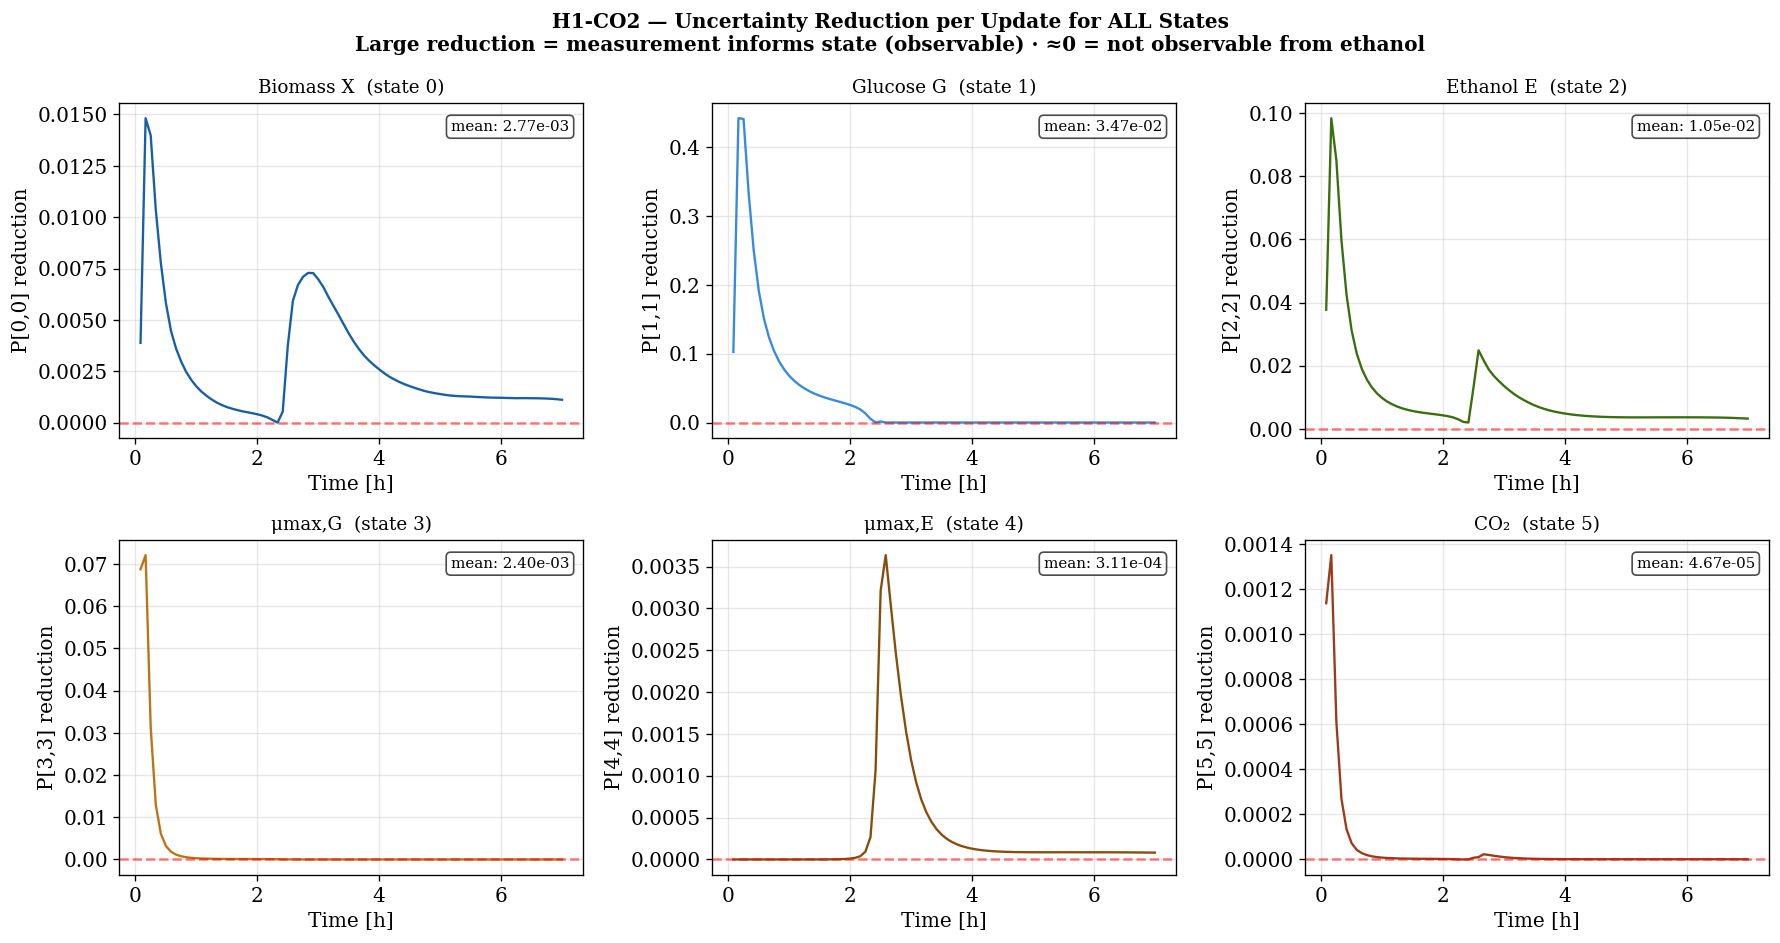

Mean uncertainty reduction per update (by state):
State         Mean reduction    Observable?
--------------------------------------------------
Biomass X     2.7687e-03        YES — informed
Glucose G     3.4720e-02        YES — informed
Ethanol E     1.0509e-02        YES — informed
μmax,G        2.3967e-03        YES — informed
μmax,E        3.1053e-04        YES — informed
CO₂           4.6711e-05        NO — model-driven


In [31]:
# ── H3-CO2 Diagnostic: Uncertainty reduction for ALL states ───────────────
# Compare P[i,i] reduction per update across all 6 states
# Large reduction = measurement informs that state (observable)
# ~0 reduction    = measurement does not help that state (not observable)

state_names = ['Biomass X', 'Glucose G', 'Ethanol E', 'μmax,G', 'μmax,E', 'CO₂']
n_states = 6

# Storage: P[i,i] before and after each update, for all states
Pii_before = {i: [] for i in range(n_states)}
Pii_after  = {i: [] for i in range(n_states)}

I6 = np.eye(6)
init_diag = np.concatenate([x0_co2, P0_co2.flatten()])
t_prev_diag = 0.0

for i, (t_now, z) in enumerate(zip(t_meas, E_measured)):

    # PREDICTION
    sol = solve_ivp(
        fun=combined_ode_co2,
        t_span=(t_prev_diag, t_now),
        y0=init_diag,
        rtol=1e-6, atol=1e-9
    )
    PS = sol.y[:6, -1]
    P  = sol.y[6:, -1].reshape(6, 6)

    # Record diagonal BEFORE update
    for s in range(n_states):
        Pii_before[s].append(P[s, s])

    # CORRECTION
    S  = H_co2 @ P @ H_co2.T + R
    K  = P @ H_co2.T @ np.linalg.inv(S)
    innovation = z - PS[2]
    FS = PS + (K @ [[innovation]]).flatten()
    IKH  = I6 - K @ H_co2
    Pflt = IKH @ P @ IKH.T + K @ R @ K.T

    # Record diagonal AFTER update
    for s in range(n_states):
        Pii_after[s].append(Pflt[s, s])

    init_diag   = np.concatenate([FS, Pflt.flatten()])
    t_prev_diag = t_now

# Convert to arrays and compute reduction
reduction = {}
for s in range(n_states):
    Pii_before[s] = np.array(Pii_before[s])
    Pii_after[s]  = np.array(Pii_after[s])
    reduction[s]  = Pii_before[s] - Pii_after[s]

# ── Plot: 2x3 grid, one reduction panel per state ─────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
fig.suptitle('H1-CO2 — Uncertainty Reduction per Update for ALL States\n'
             'Large reduction = measurement informs state (observable) · '
             '≈0 = not observable from ethanol',
             fontsize=12, fontweight='bold')

colors = ['#185FA5', '#378ADD', '#3B6D11', '#BA7517', '#854F0B', '#993C1D']

for s in range(n_states):
    ax = axes[s // 3, s % 3]
    ax.plot(t_meas, reduction[s], color=colors[s], lw=1.4)
    ax.axhline(0, color='red', ls='--', alpha=0.5)
    ax.set_title(f'{state_names[s]}  (state {s})', fontsize=11)
    ax.set_xlabel('Time [h]')
    ax.set_ylabel(f'P[{s},{s}] reduction')
    ax.grid(True, alpha=0.3)

    # Annotate mean reduction
    mean_red = reduction[s].mean()
    ax.text(0.97, 0.95, f'mean: {mean_red:.2e}',
            transform=ax.transAxes, ha='right', va='top',
            fontsize=9, bbox=dict(boxstyle='round', fc='white', alpha=0.7))

plt.tight_layout()
plt.savefig('figures/H1_CO2_reduction_all_states.png', dpi=150, bbox_inches='tight')
plt.show()

# ── Summary table ─────────────────────────────────────────────────────────
print("Mean uncertainty reduction per update (by state):")
print(f"{'State':<14}{'Mean reduction':<18}{'Observable?'}")
print("-" * 50)
for s in range(n_states):
    mean_red = reduction[s].mean()
    observable = 'YES — informed' if mean_red > 1e-4 else 'NO — model-driven'
    print(f"{state_names[s]:<14}{mean_red:<18.4e}{observable}")



### Citation
Yousefi-Darani, A., Paquet-Durand, O., Hitzmann, B. (2020).
*The Kalman Filter for the Supervision of Cultivation Processes.*
In: Herwig, C., Pörtner, R., Möller, J. (eds) Digital Twins.
Advances in Biochemical Engineering/Biotechnology, vol 177. Springer, Cham.
https://doi.org/10.1007/10_2020_145
